Version Check:

In [3]:
import sys

print("PYTHON:", sys.executable)

# 1) Remove wrong/conflicting accelerate + ensure clean install
!{sys.executable} -m pip -q uninstall -y accelerate

# 2) Install a compatible, pinned stack (Trainer will work)
!{sys.executable} -m pip -q install -U \
  "transformers==4.46.3" \
  "accelerate==0.34.2" \
  "datasets==2.21.0" \
  "pyarrow==18.1.0" \
  "evaluate" \
  "scikit-learn" \
  "sentence-transformers"

# 3) Verify versions (MUST match)
import transformers, accelerate, datasets, pyarrow
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("datasets:", datasets.__version__)
print("pyarrow:", pyarrow.__version__)

PYTHON: /Users/lylaliu/miniconda3/envs/sst2-env/bin/python
transformers: 4.46.3
accelerate: 0.34.2
datasets: 2.21.0
pyarrow: 18.1.0


#### QUESTION 1

Overview:

In [4]:
%pip install gdown
import gdown

file_id = "1qOsO1ocP9WT0pK1CMK2EDNlmqemSZID8"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.csv", quiet=False)

Note: you may need to restart the kernel to use updated packages.


Downloading...
From: https://drive.google.com/uc?id=1qOsO1ocP9WT0pK1CMK2EDNlmqemSZID8
To: /Users/lylaliu/Desktop/ECE219P1/dataset.csv
100%|██████████| 14.5M/14.5M [00:00<00:00, 23.4MB/s]


'dataset.csv'

In [5]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()
df.shape

(3476, 8)

Overview: The dataset contains 3476 rows and 8 features.

Histogram (a): The total number of alpha-numeric characters per data point in the feature full_text

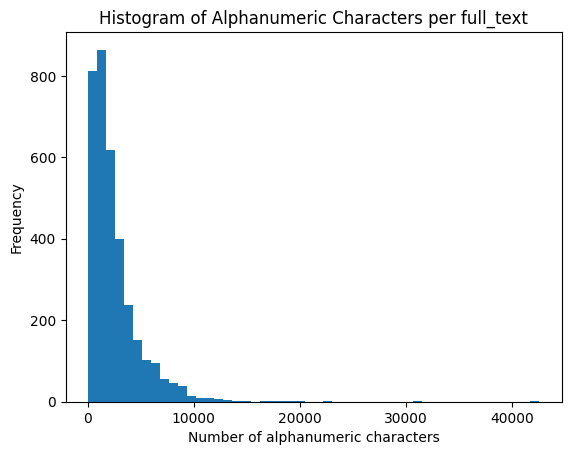

In [6]:
import re

def count_alnum(text):
    return len(re.findall(r"[A-Za-z0-9]", str(text)))

df["alnum_count"] = df["full_text"].apply(count_alnum)
df["alnum_count"].head()

import matplotlib.pyplot as plt

plt.hist(df["alnum_count"], bins=50)
plt.xlabel("Number of alphanumeric characters")
plt.ylabel("Frequency")
plt.title("Histogram of Alphanumeric Characters per full_text")
plt.show()

Histogram (b): The column leaf_label - class on the x-axis

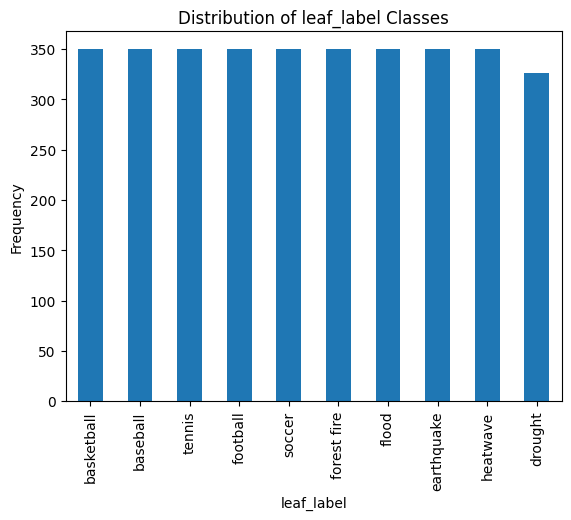

In [7]:
df["leaf_label"].value_counts().plot(kind="bar")
plt.xlabel("leaf_label")
plt.ylabel("Frequency")
plt.title("Distribution of leaf_label Classes")
plt.show()

Histogram (c): The column root_label - class on the x-axis

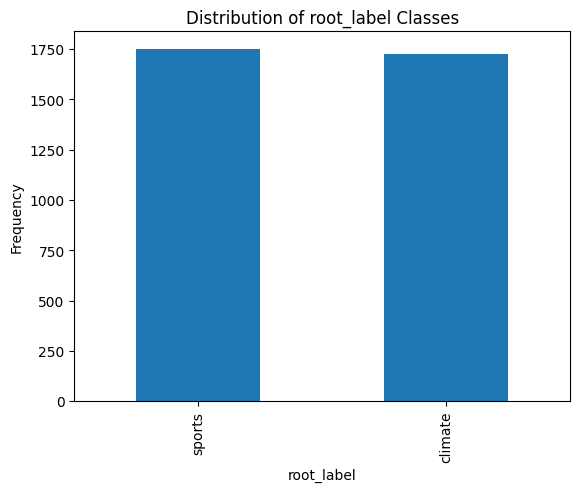

In [8]:
df["root_label"].value_counts().plot(kind="bar")
plt.xlabel("root_label")
plt.ylabel("Frequency")
plt.title("Distribution of root_label Classes")
plt.show()

Histogram interpretations:

Histogram (a): The distribution of alphanumeric character counts in full_text is right-skewed, indicating that most text samples are relatively short, while a smaller number of samples contain significantly longer text. This suggests variability in article or sentence length, which may affect downstream modeling and may require normalization or truncation.

Histogram (b): The distribution of leaf_label classes is nearly uniform, with most classes containing approximately the same number of samples. This suggests the dataset was intentionally constructed to be balanced at the leaf level, which is beneficial for training and evaluating classification models without bias toward particular classes. A slight deviation is observed for the drought class, which contains marginally fewer samples, likely due to preprocessing or filtering effects.

Histogram (c): The distribution of root_label classes is nearly balanced with samples labeled as sports and climate. This balance arises from the intentional construction of the dataset, in which each root category contains an equal number of leaf-level classes with approximately uniform sample counts. Such balance is advantageous for hierarchical classification tasks, as it prevents bias toward either top-level category during model training and evaluation.

#### QUESTION 2

In [9]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df[["full_text", "root_label", "leaf_label"]],
    test_size=0.2,
    random_state=42
)

print("Number of training samples:", train.shape[0])
print("Number of testing samples:", test.shape[0])

Number of training samples: 2780
Number of testing samples: 696


Using a fixed random seed for reproducibility, the dataset was split into training and testing sets with a test fraction of 0.2. This resulted in 2,780 training samples and 696 testing samples. The same split is reused for both the root-level (binary) and leaf-level (multiclass) classification experiments to ensure consistency across evaluations.

#### QUESTION 3

In [10]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to /Users/lylaliu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lylaliu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lylaliu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/lylaliu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /Users/lylaliu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/lylaliu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
# Helper functions

import re
def clean(text):
    text = re.sub(r'^https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    texter = re.sub(r"<br />", " ", text)
    texter = re.sub(r"&quot;", "\"",texter)
    texter = re.sub('&#39;', "\"", texter)
    texter = re.sub('\n', " ", texter)
    texter = re.sub(' u '," you ", texter)
    texter = re.sub('`',"", texter)
    texter = re.sub(' +', ' ', texter)
    texter = re.sub(r"(!)\1+", r"!", texter)
    texter = re.sub(r"(\?)\1+", r"?", texter)
    texter = re.sub('&amp;', 'and', texter)
    texter = re.sub('\r', ' ',texter)
    clean = re.compile('<.*?>')
    texter = texter.encode('ascii', 'ignore').decode('ascii')
    texter = re.sub(clean, '', texter)
    if texter == "":
        texter = ""
    return texter

# Judge if a tag is num
_num_pattern = re.compile(r"^[+-]?(\d+(\.\d*)?|\.\d+)$")
def is_number(text):
    return bool(_num_pattern.match(text)) 

# penn2morphy helper function (speech conversion)
def penn2morphy(penntag):
    """ Converts Penn Treebank tags to WordNet. """
    morphy_tag = {'NN':'n', 'JJ':'a',
                  'VB':'v', 'RB':'r'}
    try:
        return morphy_tag[penntag[:2]]
    except:
        return 'n'


In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline


import nltk

# Core tokenization + tagging
nltk.download("punkt")
nltk.download("punkt_tab") 
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
# Lemmatization
nltk.download("wordnet")
nltk.download("omw-1.4")

# Optional (only if your clean() uses stopwords)
nltk.download("stopwords")


from nltk import word_tokenize, pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def my_tokenizer(doc):
    #Preprocessing with clean
    doc = clean(doc)
    tokens = word_tokenize(doc)
    tagged = pos_tag(tokens)

    #remove numbers:
    out = []
    for word, tag in tagged:
        word = word.lower()
        if is_number(word):
            continue
        if not any(ch.isalnum() for ch in word): #optional, to clean the punctuations
            continue
        wordnet_tag = penn2morphy(tag)
        lemma = lemmatizer.lemmatize(word, pos=wordnet_tag)
        out.append(lemma)
    return out

count_vect = CountVectorizer(min_df=3, stop_words='english', tokenizer=my_tokenizer)
tfidf_pipeline = Pipeline([
    ("vectorizer", count_vect),
    ("tfidf", TfidfTransformer())   
])
X_train_tfidf = tfidf_pipeline.fit_transform(train["full_text"])
X_test_tfidf = tfidf_pipeline.transform(test["full_text"])

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)
        



[nltk_data] Downloading package punkt to /Users/lylaliu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lylaliu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/lylaliu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/lylaliu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /Users/lylaliu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/lylaliu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lylaliu/nltk_data.

/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['far', 'make', 'u'] not in stop_words.
  warnings.warn(


TF-IDF train shape: (2780, 14542)
TF-IDF test shape: (696, 14542)


**Answer**:

**1.** Compared with stemming, which ignores the grammatical roles of a word, lemmatization care about the dictionary form/lemma of words. As a result, it can preserve the semantic meanings more accurate than stemming while more computational heavy due to extra POS tagging and lookup steps. 

**2.** Min_df defines the minimum number of documents a word must appear in to be considered. Larger min_df leads to a smaller TF_IDF matrix, because more infrequent words will be filtered out.

**3.** Because POS tagging benefits from the entire sentence context, it is better to tokenize and POS-tag first, then remove stopwords/punctuations/numbers, and finally apply lemmatization.

**4.** TF-IDF train shape: (2780, 14542), TF-IDF test  shape: (696, 14542)

#### QUESTION 4

**Answer**:

**(a)** The probabilities themselves cannot capture semantic relationships becasue they will be influenced by high-frequency but non-discriminative words. However, the ratio can cancel out the noise from non-discriminative words thus preserving the correlation between words that reflects their underlying semantic distinctions. 

**(b)** They have the same word embeddings in GloVe, because one word type corresponds to a single vector learned from global co-occurrence statistics. 

**(c)** Expectation(may be need to modify this): $$||GloVE(wife) - GloVE(husband)||_2 < ||GloVE(left) - GloVE(right)||_2  << ||GloVE(wife) - GloVE(orange)||_2$$ 
orange and wife should have the largest diff because they are the most unrelated pair. The distance between left and right may be larger than that of wife and husband due to their functional opposition

**(d)** Lemmatization is preferred because it produces valid word forms that are more likely to appear in GloVE vocabulary, but stemming may generate non-standard tokens that result in out-of-vocabulary embeddings.

#### QUESTION 5

**Answer**:

**(a)** To construct document-level embeddings using GloVe, we first preprocess each document using the tokenizer defined previously. For each token in a document, we look up the corresponding word embedding from the GloVe vocabulary if it exists. Tokens that are not covered by the GloVe vocabulary are ignored. The document embedding is then obtained by averaging the word embeddings within the document, resulting in a single 300-dimensional representation.

In [13]:
# (b)
#Read GloVe
embeddings_dict = {}
dimension_of_glove = 300

with open("glove/glove.6B.300d.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], "float32")
        embeddings_dict[word] = vector

    

In [14]:
def document_to_glove_embedding(doc, emb_dict, dim=300):
    tokens = my_tokenizer(doc)
    doc_embs = []
    oovs = 0

    for token in tokens:
        vec = emb_dict.get(token)
        if vec is None:
            oovs += 1
        else:
            doc_embs.append(vec)

    # handle empty doc_embs
    if len(doc_embs) == 0:
        glove_doc = np.zeros(dim, dtype=np.float32)
    else:
        glove_doc = np.mean(doc_embs, axis=0).astype(np.float32)

    return len(tokens), oovs, glove_doc


train_oovs = 0
test_oovs = 0
train_token_len = 0
test_token_len = 0

X_train_glove = []
X_test_glove = []

for doc in train["full_text"]:
    token_len, oovs, glove_doc = document_to_glove_embedding(doc, embeddings_dict, dim=300)
    train_oovs += oovs
    train_token_len += token_len
    X_train_glove.append(glove_doc)

X_train_glove = np.vstack(X_train_glove)
train_oov_rate = train_oovs / max(train_token_len, 1)


for doc in test["full_text"]:
    token_len, oovs, glove_doc = document_to_glove_embedding(doc, embeddings_dict, dim=300)
    test_oovs += oovs
    test_token_len += token_len
    X_test_glove.append(glove_doc)

X_test_glove = np.vstack(X_test_glove)
test_oov_rate = test_oovs / max(test_token_len, 1)


print(f"Shape of train embedding matrix: {X_train_glove.shape}")
print(f"Train oov rate: {train_oov_rate}")
print(f"Shape of test embedding matrix: {X_test_glove.shape}")
print(f"Test oov rate: {test_oov_rate}")



    

Shape of train embedding matrix: (2780, 300)
Train oov rate: 0.01804826877690653
Shape of test embedding matrix: (696, 300)
Test oov rate: 0.01812800108679182


#### QUESTION 6

In [15]:
!pip -q install transformers torch

import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"  # allowed example
MAX_LEN = 512   # use 512 for “handling long docs” reporting
BATCH_SIZE = 32 # reduce to 16 if you get OOM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
enc = AutoModel.from_pretrained(MODEL_NAME).to(device)
enc.eval()

@torch.no_grad()
def encode_texts(texts):
    all_vecs = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i+BATCH_SIZE]
        inputs = tok(
            batch,
            truncation=True,
            max_length=MAX_LEN,
            padding=True,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = enc(**inputs)

        # mean pooling with attention mask
        mask = inputs["attention_mask"].unsqueeze(-1).type_as(out.last_hidden_state)
        pooled = (out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)

        all_vecs.append(pooled.cpu())

    return torch.cat(all_vecs, dim=0)


In [16]:
# Q2: 2780 rows, test has 696 rows

all_texts = pd.concat([train["full_text"], test["full_text"]], axis=0).astype(str).tolist()

# token lengths without truncation
lengths = []
for i in range(0, len(all_texts), 256):
    batch = all_texts[i:i+256]
    ids = tok(batch, add_special_tokens=True, truncation=False)["input_ids"]
    lengths.extend([len(x) for x in ids])

lengths = np.array(lengths)
frac_truncated = (lengths > MAX_LEN).mean()

print("MAX_LEN =", MAX_LEN)
print("Fraction of documents that would be truncated:", frac_truncated)
print("Average token length:", lengths.mean())
print("95th percentile token length:", np.percentile(lengths, 95))


Token indices sequence length is longer than the specified maximum sequence length for this model (2595 > 512). Running this sequence through the model will result in indexing errors


MAX_LEN = 512
Fraction of documents that would be truncated: 0.48216340621403914
Average token length: 686.117088607595
95th percentile token length: 2012.75


In [17]:
X_train_emb = encode_texts(train["full_text"].astype(str).tolist())
X_test_emb  = encode_texts(test["full_text"].astype(str).tolist())

print("Train embedding matrix shape:", tuple(X_train_emb.shape))
print("Test embedding matrix shape:", tuple(X_test_emb.shape))

embedding_dim = X_train_emb.shape[1]
print("Embedding dimension:", embedding_dim)


Train embedding matrix shape: (2780, 384)
Test embedding matrix shape: (696, 384)
Embedding dimension: 384


**Answer**:

We use a pretrained Transformer encoder, sentence-transformers/all-MiniLM-L6-v2, as a document embedding model to generate fixed-length vector representations for each news article based on the full_text field. Token-level embeddings produced by the encoder are aggregated using mean pooling over non-padded tokens to obtain a single embedding per document.

- **a)** Transformer encoders have a maximum input length of 512 tokens. To handle long documents, we adopt a truncation strategy, where each article is truncated to the first 512 tokens prior to encoding. Under this setting, approximately 48.2% of documents are truncated. The average document length is 686 tokens, and the 95th percentile document length is approximately 2013 tokens, indicating that a substantial portion of the dataset exceeds the model’s maximum input length. Truncation provides a simple and computationally efficient approach while maintaining compatibility with the pretrained encoder.

- **b)** Using the pretrained encoder, we compute document-level embeddings for both the training and testing sets. The resulting embedding matrices have shape (2780, 384) for the training set and (696, 384) for the testing set. The embedding dimension produced by the model is 384.

#### QUESTION 7

##### Q7.1 TF-IDF + LSI (TruncatedSVD)

k=   1  cumulative explained variance=0.0061
k=   5  cumulative explained variance=0.0709
k=  10  cumulative explained variance=0.1146
k=  25  cumulative explained variance=0.1953
k=  50  cumulative explained variance=0.2704
k= 100  cumulative explained variance=0.3584
k= 500  cumulative explained variance=0.6705
k=1000  cumulative explained variance=0.8498


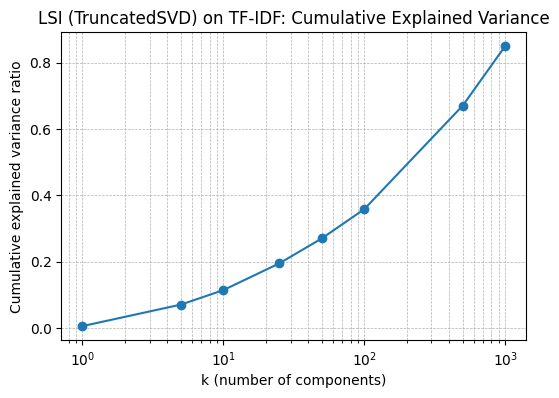

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

k_list = [1, 5, 10, 25, 50, 100, 500, 1000]

cum_var = []
for k in k_list:
    svd = TruncatedSVD(n_components=k, random_state=42)
    svd.fit(X_train_tfidf)
    cum_var.append(svd.explained_variance_ratio_.sum())
    print(f"k={k:4d}  cumulative explained variance={cum_var[-1]:.4f}")

plt.figure(figsize=(6,4))
plt.plot(k_list, cum_var, marker="o")
plt.xscale("log")
plt.xlabel("k (number of components)")
plt.ylabel("Cumulative explained variance ratio")
plt.title("LSI (TruncatedSVD) on TF-IDF: Cumulative Explained Variance")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

In [19]:
k = 25
svd_25 = TruncatedSVD(n_components=k, random_state=42)

X_train_lsi = svd_25.fit_transform(X_train_tfidf)
X_test_lsi  = svd_25.transform(X_test_tfidf)

print("LSI train shape:", X_train_lsi.shape)
print("LSI test  shape:", X_test_lsi.shape)

LSI train shape: (2780, 25)
LSI test  shape: (696, 25)


Q7.1 Answer:

We apply Latent Semantic Indexing (LSI) using Truncated Singular Value Decomposition (TruncatedSVD) on the TF–IDF training matrix and evaluate the cumulative explained variance ratio for different numbers of components $k \in \{1,5,10,25,50,100,500,1000\}$.

The cumulative explained variance increases monotonically with k, reaching approximately 0.195 at k = 25, 0.358 at k = 100, and 0.850 at k = 1000. This indicates that TF–IDF representations are highly high-dimensional and sparse, requiring many components to capture most of the variance. Following the project instructions, we fix k = 25 for subsequent experiments as a reasonable trade-off between dimensionality reduction and information preservation.

Using k=25, the reduced data matrices have the following shapes:

- LSI train matrix: (2780,25)

- LSI test matrix: (696,25)


##### Q7.2 TF-IDF + NMF (k=25) + Reconstruction MSE

In [20]:
from sklearn.decomposition import NMF

k = 25
nmf_25 = NMF(
    n_components=k,
    init="nndsvda",
    random_state=42,
    max_iter=400
)

W_train = nmf_25.fit_transform(X_train_tfidf)   # (n_train, k)
H = nmf_25.components_                          # (k, V)

W_test = nmf_25.transform(X_test_tfidf)         # (n_test, k)

print("NMF train shape:", W_train.shape)
print("NMF test  shape:", W_test.shape)
print("H shape:", H.shape)

NMF train shape: (2780, 25)
NMF test  shape: (696, 25)
H shape: (25, 14542)


In [21]:
from sklearn.metrics import mean_squared_error
from scipy import sparse

def fro_mse(X, X_hat):
    diff = X - X_hat
    n, m = X.shape

    # sparse diff: use sparse power
    if sparse.issparse(diff):
        sq_sum = diff.power(2).sum()

    else:
        # if diff is np.matrix, force ndarray so ** is elementwise
        diff = np.asarray(diff)
        sq_sum = np.sum(diff * diff)

    return float(sq_sum) / (n * m)

# ----- LSI reconstruction on TRAIN -----
# For TruncatedSVD: X_hat ≈ (X @ V^T) @ V
Vt = svd_25.components_              # (k, V)
X_hat_lsi = X_train_lsi @ Vt         # (n_train, V)

mse_lsi = fro_mse(X_train_tfidf, X_hat_lsi)

# ----- NMF reconstruction on TRAIN -----
X_hat_nmf = W_train @ H              # (n_train, V)
mse_nmf = fro_mse(X_train_tfidf, X_hat_nmf)

print("Reconstruction MSE (LSI, k=25):", mse_lsi)
print("Reconstruction MSE (NMF, k=25):", mse_nmf)


Reconstruction MSE (LSI, k=25): 5.3577945938137965e-05
Reconstruction MSE (NMF, k=25): 5.396199624010721e-05


Q7.2 Answer:
We also apply Non-negative Matrix Factorization (NMF) with k = 25 components on the TF–IDF training matrix and transform both training and testing data using the learned factors.

The resulting matrix shapes are:
- NMF train matrix (W): (2780,25)

- NMF test matrix (W_test): (696,25)

- Topic matrix (H): (25,14542)

To compare LSI and NMF, we compute the reconstruction Mean Squared Error (MSE) on the training TF–IDF matrix using the Frobenius norm:
$$MSE = \frac{1}{nm}||X - \hat{X}||^2_F$$

The reconstruction errors are:

- LSI (k=25): $5.36 \times 10^{-5}$

- NMF (k=25): $5.40 \times 10^{-5}$

LSI achieves a slightly lower reconstruction error than NMF at the same rank.

LSI (TruncatedSVD) yields lower reconstruction error because SVD provides the optimal rank-k approximation under the Frobenius norm without constraints. In contrast, NMF imposes non-negativity constraints, which improve interpretability but restrict the solution space, leading to a slightly higher reconstruction error. This behavior is expected and consistent with the theoretical properties of the two methods.

#### QUESTION 8




Hard margin (C=2000)
Accuracy: 0.9468390804597702
Precision: 0.9509536784741145
Recall: 0.9483695652173914
F1: 0.9496598639455782


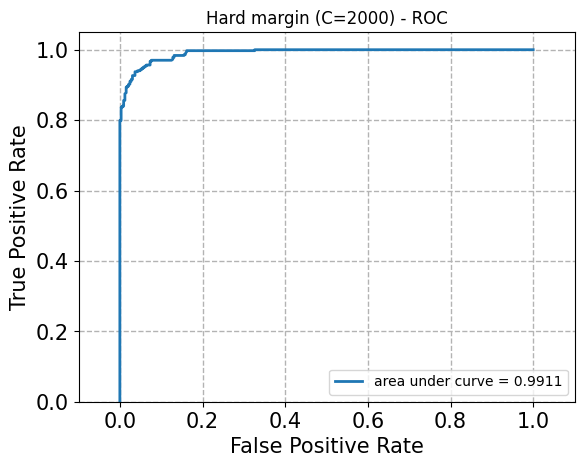

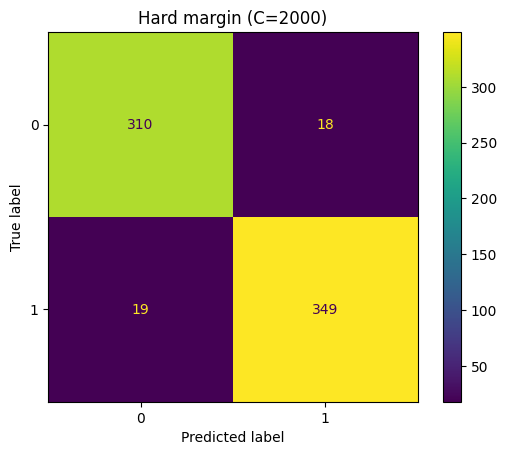


Soft margin (C=0.0005)
Accuracy: 0.9310344827586207
Precision: 0.9301075268817204
Recall: 0.9402173913043478
F1: 0.9351351351351351


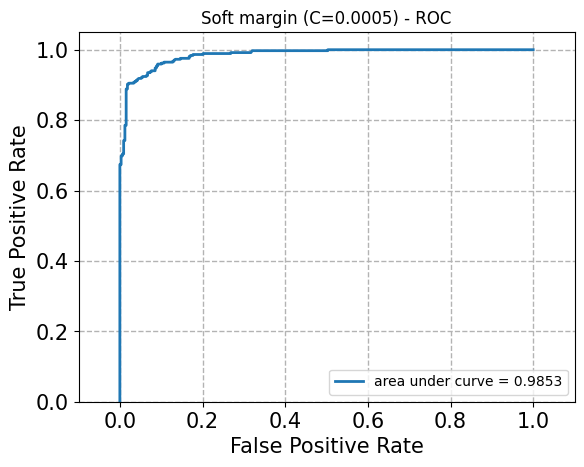

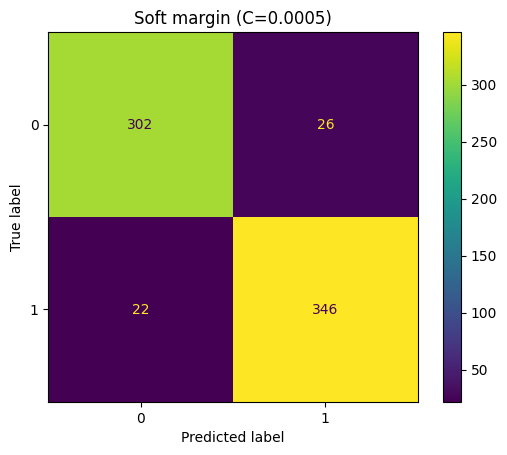


Harder margin (C=100000)
Accuracy: 0.9468390804597702
Precision: 0.9509536784741145
Recall: 0.9483695652173914
F1: 0.9496598639455782


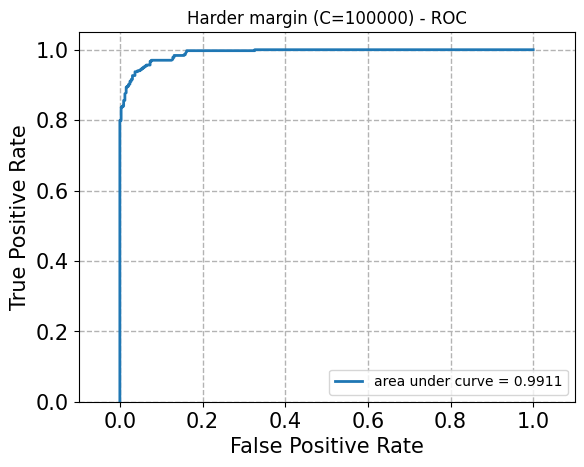

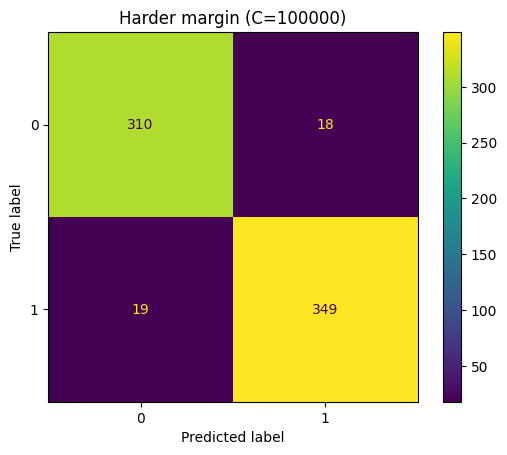

In [22]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Q8.1
y_train_svm = (train["root_label"].values == "sports").astype(int)
y_test_svm  = (test["root_label"].values == "sports").astype(int)

# Computer the eval metrics for a particular linear SVM
def eval_svm(X_train, y_train, X_test, y_test, C):
    clf = LinearSVC(C=C, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_score = clf.decision_function(X_test)

    # evaluation 
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    return {
        "cm": cm,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
    }

def plot_roc(fpr, tpr, title=None): # Add title to the original helper function
    fig, ax = plt.subplots()
    plt.grid(True)
    roc_auc = auc(fpr,tpr)

    ax.plot(fpr, tpr, lw=2, label= 'area under curve = %0.4f' % roc_auc)

    ax.grid(color='0.7', linestyle='--', linewidth=1)

    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate',fontsize=15)
    ax.set_ylabel('True Positive Rate',fontsize=15)
    if title:
        ax.set_title(title)

    ax.legend(loc="lower right")

    for label in ax.get_xticklabels()+ax.get_yticklabels():
        label.set_fontsize(15)

hard = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=2000)
soft = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=0.0005)
harder = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=100000)

for name, res in [("Hard margin (C=2000)", hard),
                  ("Soft margin (C=0.0005)", soft),
                  ("Harder margin (C=100000)", harder)]:
    print(f"\n{name}")
    print(f"Accuracy: {res['accuracy']}")
    print(f"Precision: {res['precision']}")
    print(f"Recall: {res['recall']}")
    print(f"F1: {res['f1']}")
    plot_roc(res["fpr"], res["tpr"], title=name + " - ROC")
    ConfusionMatrixDisplay(res["cm"]).plot()
    plt.title(name)
    plt.show()
    


**Answer(8.1)**:

**(1)** On the test dataset, Hard margin SVM (Accuracy 0.9468, Precision 0.9510, Recall 0.9484, F1 0.9497, AUC 0.991) performs slightly bettern than Soft margin SVM (Accuracy 0.9310, Precision 0.9301, Recall 0.9402, F1 0.9351, AUC 0.985) for all metrics.
When increasing gamma to 100000, we got exactly the same result as the hard margin svm, which indicate that if the classifier has already reached a hard margin solution, increasing of gamma will not change the decision boundary in linear SVMs.

**(2)** For the soft margin SVM, with gamma = 0.0005, the penalty of misclassification is weak. As a result, the margin is too broad and less discriminative.
In the confusion matrix, the number of false positives and false negatives, especially false positives (sports classified as climate), are increased compared with hard margin SVM, leading to lower accuracy, precision, recall and F1 score. Since the positive class (sports) exhibits more consistent feature patterns than the negative class (climate), this relaxation disproportionately increases false positives rather than false negatives.
The ROC curve partially reflects the degraded performance of the soft-margin SVM. because it reflects how well the model ranks positive samples above negative samples, but not its performance at a single fixed threshold.


Best C: 10, with accuracy score: 0.9507194244604318, List:[0.9334532374100719, 0.9345323741007195, 0.9381294964028777, 0.9446043165467625, 0.9507194244604318, 0.9496402877697843, 0.95, 0.9496402877697843, 0.9496402877697843, 0.9496402877697843]

Best SVM on test:
Best C: 10
Accuracy: 0.9425287356321839
Precision: 0.9456521739130435
Recall: 0.9456521739130435
F1: 0.9456521739130435


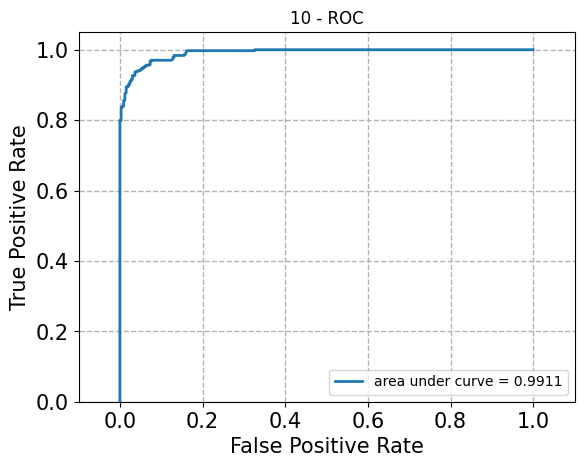

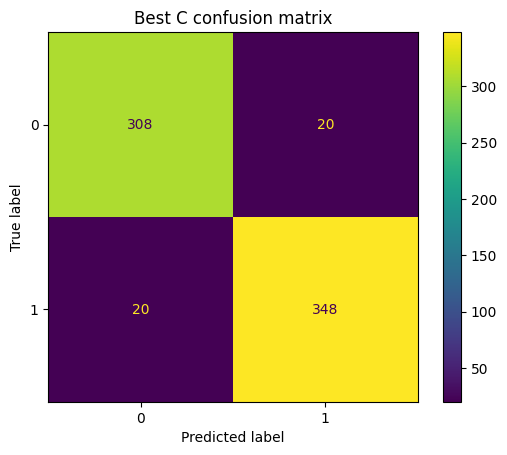

In [23]:
# Q8.2
Cs = [10 ** k for k in range(-3, 7)]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mean_scores = []
for C in Cs:
    clf = LinearSVC(C=C, random_state=42)
    scores = cross_val_score(clf, X_train_lsi, y_train_svm, cv=cv, scoring="accuracy")
    mean_scores.append(np.mean(scores))

best_C = Cs[int(np.argmax(mean_scores))]
best_score = np.max(mean_scores)
print(f"Best C: {best_C}, with accuracy score: {best_score}, List:{mean_scores}")

best_res = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=best_C)
print(f"\nBest SVM on test:")
print(f"Best C: {best_C}")
print(f"Accuracy: {best_res['accuracy']}")
print(f"Precision: {best_res['precision']}")
print(f"Recall: {best_res['recall']}")
print(f"F1: {best_res['f1']}")
plot_roc(res["fpr"], res["tpr"], title=str(best_C) + " - ROC")
ConfusionMatrixDisplay(best_res["cm"]).plot()
plt.title("Best C confusion matrix")
plt.show()

    

#### QUESTION 9

In [24]:
from sklearn.linear_model import LogisticRegression

def eval_logreg(X_train, y_train, X_test, y_test, penalty, C, solver="lbfgs", max_iter=5000):
    clf = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=max_iter, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)[:, 1]
    
    # evaluation 
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    return {
        "cm": cm,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
    }
    


LogReg (no regularization)
Accuracy: 0.9482758620689655
Precision: 0.9510869565217391
Recall: 0.9510869565217391
F1: 0.9510869565217391


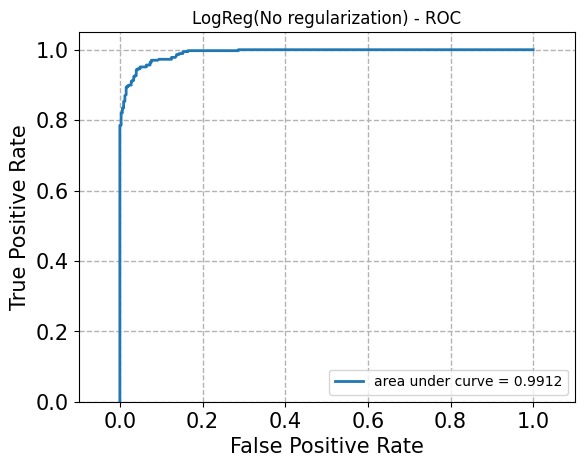

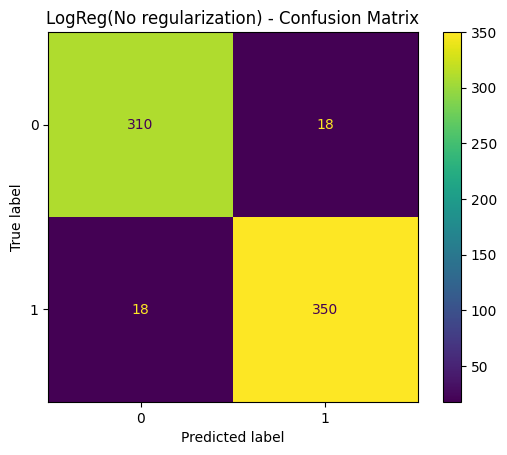

In [25]:
# Q9.1: No regularization + ROC + metrics
res_none = eval_logreg(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, penalty="l2", C=1e6)  # Using large C to approximate no regularization

print("\nLogReg (no regularization)")
print(f"Accuracy: {res_none['accuracy']}")
print(f"Precision: {res_none['precision']}")
print(f"Recall: {res_none['recall']}")
print(f"F1: {res_none['f1']}")

plot_roc(res_none["fpr"], res_none["tpr"], title="LogReg(No regularization) - ROC")

ConfusionMatrixDisplay(res_none["cm"]).plot()
plt.title("LogReg(No regularization) - Confusion Matrix")
plt.show()



Best L1: C=100 (CV acc=0.9507194244604318), lambda=1/C=0.01
Best L2: C=100 (CV acc=0.9514388489208633), lambda=1/C=0.01

LogReg L1 (best C)
Accuracy: 0.9482758620689655
Precision: 0.9510869565217391
Recall: 0.9510869565217391
F1: 0.9510869565217391
AUC: 0.9911022004241783

LogReg L2 (best C)
Accuracy: 0.9454022988505747
Precision: 0.9483695652173914
Recall: 0.9483695652173914
F1: 0.9483695652173914
AUC: 0.9912678950159067

LogReg (no regularization)
Accuracy: 0.9482758620689655
Precision: 0.9510869565217391
Recall: 0.9510869565217391
F1: 0.9510869565217391
AUC: 0.9912430408271473


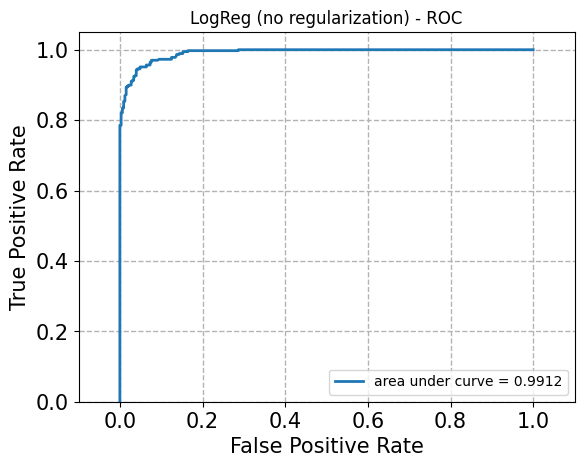

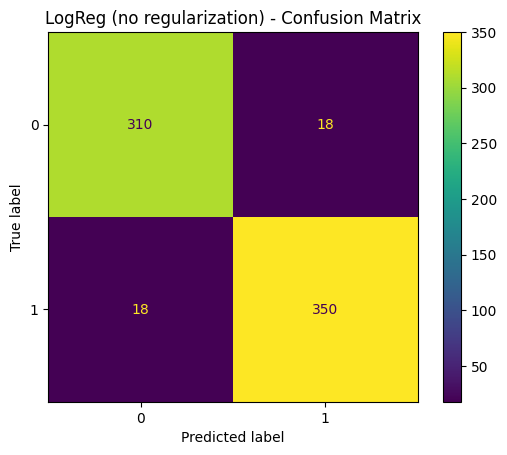

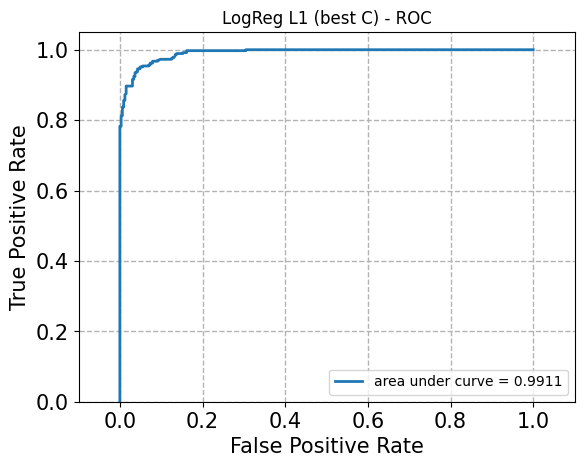

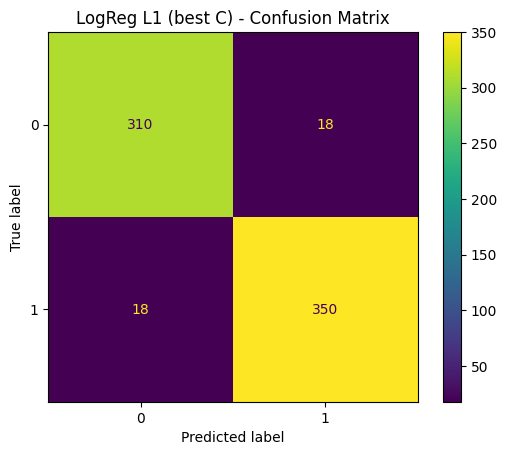

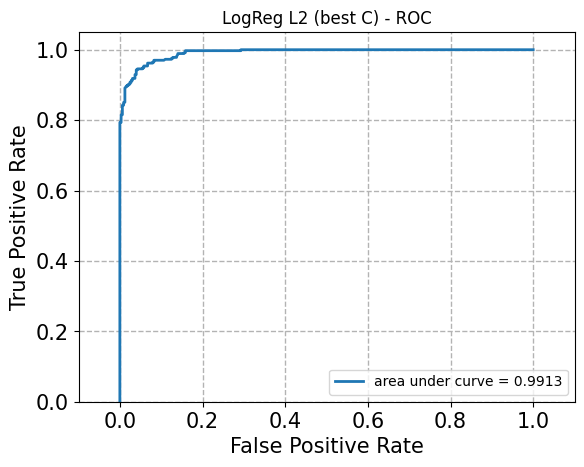

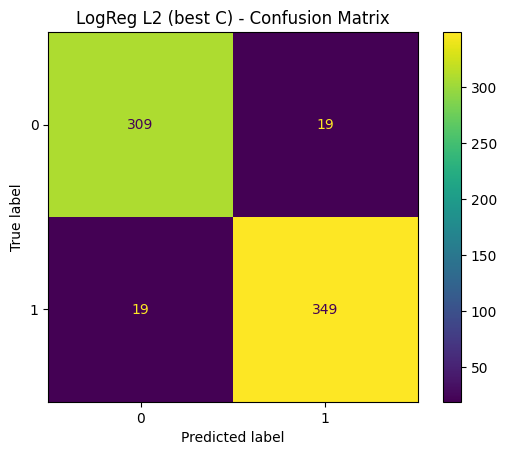

In [26]:
# Q9.2.1: cross validation (l1/l2) to find best C
Cs = [10 ** k for k in range(-5, 6)]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def find_best_C(penalty, X_train, y_train):
    if penalty == "l1":
        solver = "liblinear"
    elif penalty == "l2":
        solver = "lbfgs"
    else:
        raise ValueError("penalty must be 'l1' or 'l2'")

    mean_scores = []
    for C in Cs:
        clf = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=5000, random_state=42)
        scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy")
        mean_scores.append(scores.mean())

    best_idx = int(np.argmax(mean_scores))
    # print(mean_scores)
    return Cs[best_idx], mean_scores[best_idx], solver, mean_scores


bestC_l1, bestAcc_l1, solver_l1, l1_scores = find_best_C("l1", X_train_lsi, y_train_svm)
bestC_l2, bestAcc_l2, solver_l2, l2_scores = find_best_C("l2", X_train_lsi, y_train_svm)

print(f"\nBest L1: C={bestC_l1} (CV acc={bestAcc_l1}), lambda=1/C={1/bestC_l1}")
print(f"Best L2: C={bestC_l2} (CV acc={bestAcc_l2}), lambda=1/C={1/bestC_l2}")

# Q9.2.2 Evaluate best Cs on test set
res_l1 = eval_logreg(
    X_train_lsi, y_train_svm, X_test_lsi, y_test_svm,
    penalty="l1", C=bestC_l1, solver=solver_l1
)
res_l2 = eval_logreg(
    X_train_lsi, y_train_svm, X_test_lsi, y_test_svm,
    penalty="l2", C=bestC_l2, solver=solver_l2
)

def print_res(name, res):
    print(f"\n{name}")
    print(f"Accuracy: {res['accuracy']}")
    print(f"Precision: {res['precision']}")
    print(f"Recall: {res['recall']}")
    print(f"F1: {res['f1']}")
    print(f"AUC: {res['auc']}")

print_res("LogReg L1 (best C)", res_l1)
print_res("LogReg L2 (best C)", res_l2)
print_res("LogReg (no regularization)", res_none)

for title, res in [
    ("LogReg (no regularization)", res_none),
    ("LogReg L1 (best C)", res_l1),
    ("LogReg L2 (best C)", res_l2),
]:
    plot_roc(res["fpr"], res["tpr"], title=title + " - ROC")
    ConfusionMatrixDisplay(res["cm"]).plot()
    plt.title(f"{title} - Confusion Matrix")
    plt.show()

**Answer**

**9.2.3** 
- The regularization parameter balances the model complexity and the degree of fit with the training data. In general, large C (weak regularization) can lead to overfitting for noisy or high-dimensional features. On the other hand, small C may lead to underfitting and potentially higher test error because of high bias. In our experiments, the optimal values for both L1 and L2 regularization is C=100, leading to a performance close to unregularized model. A possible explanation is the low dimensionality of LSI feature space makes the model less likely to overfit the training data. 

- L1 regularization drives many coefficients to exactly zero, so it tends to produce a sparse solution (remove some of the features). It is commonly used when feature interpretability is important or when redundant features need to be removed, as it can identify a small subset of informative features.L2 regularization shrinks all coefficients toward zero while retaining all features. Compared with L1, it is easier to optimize and typically yields more stable solutions. It is commonly used when multicollinearity exists among features or when we need a stable solution.In our experiment, L1 and L2 regularization achieve very similar classification performance, with L1 performing slightly better in terms of accuracy and F1 score. However, L2 achieves a marginally higher AUC, indicating that although its decision threshold leads to slightly worse classification at a fixed cutoff, it has a slightly better ability to rank positive and negative samples overall.

**9.2.4** 
- For SVMs, we are using hinge loss to find the decision boundary. It cares more about the misclassified points and points that are difficult to classify (closer to the decision boundary), aiming at finding the maximum margin hyperplane. On the other hand, logistic regression uses cross-entropy loss. It models probabilities and cares about all data points. 

- As a result, SVM does better when there exists outliers that are far away from the decision boundaries and Logistic Regression works well when probability is required and there is a lot of noise near the decision boundary.

- In our experiment, both SVM and Logistic Regression produces similar performance, indicating that the dataset is roughly linearly separable and both models have similar decision boundaries. So the difference is not statistically significant in this particular task. 

#### QUESTION 10


GaussianNB scores on test set:
Accuracy: 0.9181034482758621
Precision: 0.8820638820638821
Recall: 0.9755434782608695
F1: 0.9264516129032258


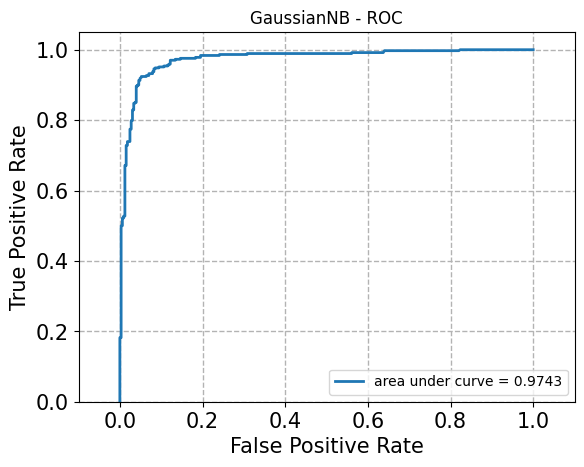

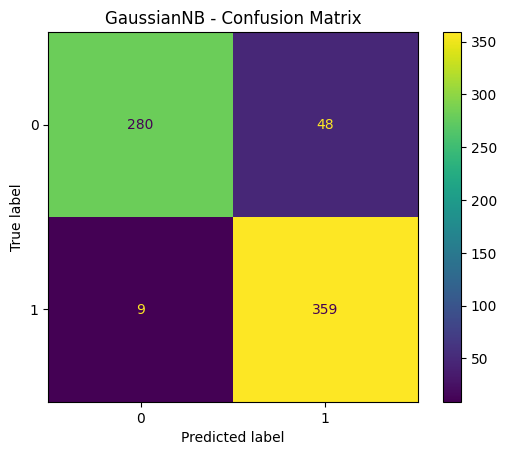

In [27]:
from sklearn.naive_bayes import GaussianNB

def eval_gnb(X_train, y_train, X_test, y_test):
    clf = GaussianNB()
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)[:, 1] # prob of sports

    # evaluation 
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    return {
        "cm": cm,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
    }

gnb = eval_gnb(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm)
print("\nGaussianNB scores on test set:")
print(f"Accuracy: {gnb['accuracy']}")
print(f"Precision: {gnb['precision']}")
print(f"Recall: {gnb['recall']}")
print(f"F1: {gnb['f1']}")

#ROC plot
plot_roc(gnb["fpr"], gnb["tpr"], title="GaussianNB - ROC")

#Confusion Matrix
ConfusionMatrixDisplay(gnb["cm"]).plot()
plt.title("GaussianNB - Confusion Matrix")
plt.show()
    

**Answer**

GaussianNB produces very few false negatives but a relatively large number of false positives, so it biased toward predicting positive(sports) class, leading to high recall. 

#### QUESTION 11

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

y_train = (train["root_label"].values == "sports").astype(int)
y_test  = (test["root_label"].values == "sports").astype(int)

X_train_text = train["full_text"].astype(str).values
X_test_text  = test["full_text"].astype(str).values

# tokenizer for lemmatizer has been defined in Q3 as my_tokenizer
tokenizer_lemma = my_tokenizer

# tokenizer for stem;
def tokenizer_stem(doc):
    doc = clean(doc)
    tokens = word_tokenize(doc)
    out = []

    for word in tokens:
        word = word.lower()
        if is_number(word):
            continue
        if not any(ch.isalnum() for ch in word):
            continue
        out.append(stemmer.stem(word))
    return out

class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else np.asarray(X) # Ensure the data is densed

best_C_svm = 10
best_C_l1 = 100
best_C_l2 = 100

pipe = Pipeline([
    ("vect", CountVectorizer(stop_words="english")),
    ("tfidf", TfidfTransformer()),
    ("reduce", TruncatedSVD(random_state=42)),
    ("clf", LinearSVC(random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


param_grid = []

# LSI + LinearSVC(SVM)
param_grid.append({
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [TruncatedSVD(random_state=42)],
    "reduce__n_components": [5, 30, 100],
    "clf": [LinearSVC(C=best_C_svm, random_state=42)],
})

# LSI + LogReg L1
param_grid.append({
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [TruncatedSVD(random_state=42)],
    "reduce__n_components": [5, 30, 100],
    "clf": [LogisticRegression(penalty="l1", solver="liblinear", C=best_C_l1, max_iter=5000, random_state=42)],
})

# LSI + LogReg L2
param_grid.append({
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [TruncatedSVD(random_state=42)],
    "reduce__n_components": [5, 30, 100],
    "clf": [LogisticRegression(penalty="l2", solver="lbfgs", C=best_C_l2, max_iter=5000, random_state=42)],
})

# LSI(SVD) + GaussianNB (diff pipe)
pipe_gnb = Pipeline([
    ("vect", CountVectorizer(stop_words="english")),
    ("tfidf", TfidfTransformer()),
    ("reduce", TruncatedSVD(random_state=42)),
    ("to_dense", DenseTransformer()),
    ("clf", GaussianNB()),
])

param_grid_gnb = [{
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [TruncatedSVD(random_state=42)],
    "reduce__n_components": [5, 30, 100],
}]

# NMF + LinearSVC(SVM)
param_grid.append({
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [NMF(init="nndsvda", random_state=42, max_iter=500)],
    "reduce__n_components": [5, 30, 100],
    "clf": [LinearSVC(C=best_C_svm, random_state=42)],
})

# NMF + LogReg L1
param_grid.append({
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [NMF(init="nndsvda", random_state=42, max_iter=500)],
    "reduce__n_components": [5, 30, 100],
    "clf": [LogisticRegression(
        penalty="l1", solver="liblinear", C=best_C_l1, max_iter=5000, random_state=42
    )],
})

# NMF + LogReg L2
param_grid.append({
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [NMF(init="nndsvda", random_state=42, max_iter=500)],
    "reduce__n_components": [5, 30, 100],
    "clf": [LogisticRegression(
        penalty="l2", solver="lbfgs", C=best_C_l2, max_iter=5000, random_state=42
    )],
})

# NMF + GaussianNB (Dense)
param_grid_gnb.append({
    "vect__min_df": [2, 5],
    "vect__tokenizer": [tokenizer_lemma, tokenizer_stem],
    "reduce": [NMF(init="nndsvda", random_state=42, max_iter=500)],
    "reduce__n_components": [5, 30, 100],
})

# Conduct grid search
grid = GridSearchCV(
    pipe, param_grid=param_grid, scoring="accuracy", cv=cv,
    n_jobs=-1, verbose=1
)
grid.fit(X_train_text, y_train)

grid_gnb = GridSearchCV(
    pipe_gnb, param_grid=param_grid_gnb, scoring="accuracy", cv=cv,
    n_jobs=-1, verbose=1
)
grid_gnb.fit(X_train_text, y_train)



Fitting 5 folds for each of 72 candidates, totalling 360 fits


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parame

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['far', 'make', 'u'] not in stop_words.
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['far', 'make', 'u'] not in stop_words.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('vect',
                                        CountVectorizer(stop_words='english')),
                                       ('tfidf', TfidfTransformer()),
                                       ('reduce',
                                        TruncatedSVD(random_state=42)),
                                       ('to_dense', DenseTransformer()),
                                       ('clf', GaussianNB())]),
             n_jobs=-1,
             param_grid=[{'reduce': [TruncatedSVD(random_state=42)],
                          'reduce__n_comp...
                          'vect__min_df': [2, 5],
                          'vect__tokenizer': [<function my_tokenizer at 0x34fb303a0>,
                                              <function tokenizer_stem at 0x333939c60>]},
                         {'reduce': [NMF(init='nndsvda', max_iter=500,
                                         random_state=42)],
                          'reduce__n_components': [5, 30, 100],
                          'vect__min_df': [2, 5],
                          'vect__tokenizer': [<function my_tokenizer at 0x34fb303a0>,
                                              <function tokenizer_stem at 0x333939c60>]}],
             scoring='accuracy', verbose=1)

Top-5 by accuracy: 


,source,mean_test_score,rank_test_score,params
0,general,0.962590,1,"{'clf': LogisticRegression(C=100, max_iter=5000, random_state=42), 'reduce': TruncatedSVD(random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function tokenizer_stem at 0x333939c60>}"
2,general,0.962230,2,"{'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function tokenizer_stem at 0x333939c60>}"
1,general,0.962230,2,"{'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(random_state=42), 'reduce__n_components': 100, 'vect__min_df': 2, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}"
3,general,0.961151,4,"{'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}"
4,general,0.960072,5,"{'clf': LogisticRegression(C=100, max_iter=5000, random_state=42), 'reduce': TruncatedSVD(random_state=42), 'reduce__n_components': 100, 'vect__min_df': 2, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}"


/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'formerli', 'forti', 'ha', 'henc', 'hereaft', 'herebi', 'hi', 'howev', 'hundr', 'inde', 'latterli', 'mani', 'meanwhil', 'moreov', 'mostli', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'seriou', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim',

/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,rank,cv_acc,test_acc,test_prec,test_rec,test_f1,params
0,1,0.962590,0.964080,0.975069,0.956522,0.965706,"{'clf': LogisticRegression(C=100, max_iter=5000, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function tokenizer_stem at 0x333939c60>}"
1,2,0.962230,0.969828,0.980609,0.961957,0.971193,"{'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function tokenizer_stem at 0x333939c60>}"
2,3,0.962230,0.968391,0.977901,0.961957,0.969863,"{'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 2, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}"
3,4,0.961151,0.972701,0.980716,0.967391,0.974008,"{'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}"
4,5,0.960072,0.971264,0.980663,0.964674,0.972603,"{'clf': LogisticRegression(C=100, max_iter=5000, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 2, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}"



Top 1 | Cv acc=0.9625899280575541 | Test acc=0.9640804597701149
Params: {'clf': LogisticRegression(C=100, max_iter=5000, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function tokenizer_stem at 0x333939c60>}


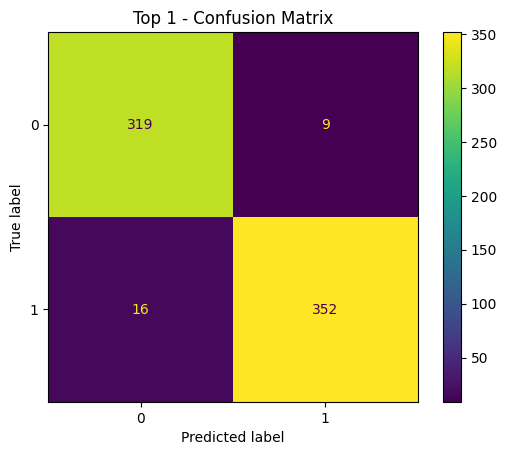


Top 2 | Cv acc=0.9622302158273381 | Test acc=0.9698275862068966
Params: {'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function tokenizer_stem at 0x333939c60>}


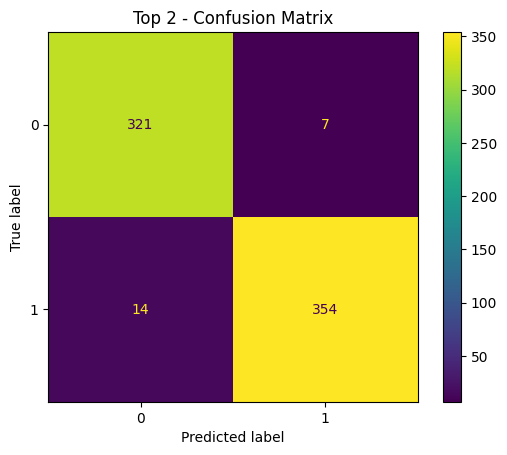


Top 3 | Cv acc=0.9622302158273381 | Test acc=0.9683908045977011
Params: {'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 2, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}


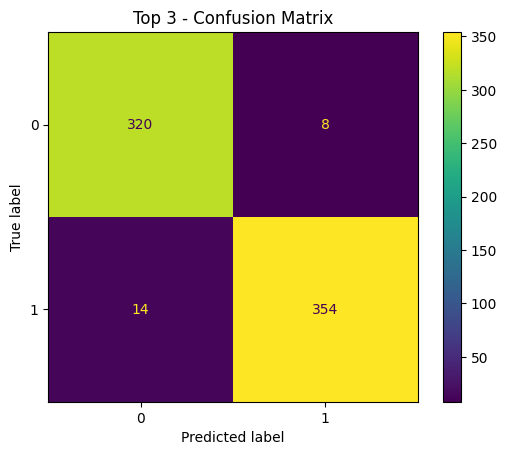


Top 4 | Cv acc=0.9611510791366907 | Test acc=0.9727011494252874
Params: {'clf': LinearSVC(C=10, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 5, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}


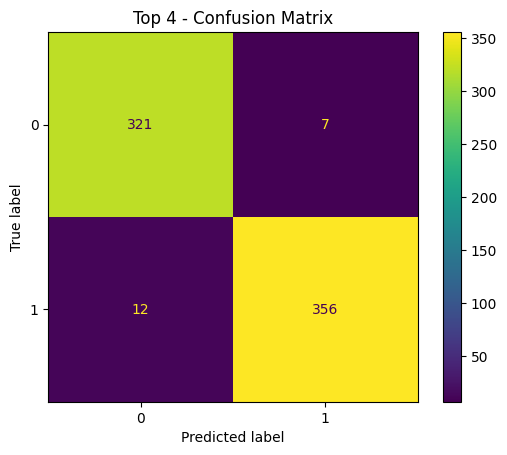


Top 5 | Cv acc=0.9600719424460431 | Test acc=0.9712643678160919
Params: {'clf': LogisticRegression(C=100, max_iter=5000, random_state=42), 'reduce': TruncatedSVD(n_components=100, random_state=42), 'reduce__n_components': 100, 'vect__min_df': 2, 'vect__tokenizer': <function my_tokenizer at 0x34fb303a0>}


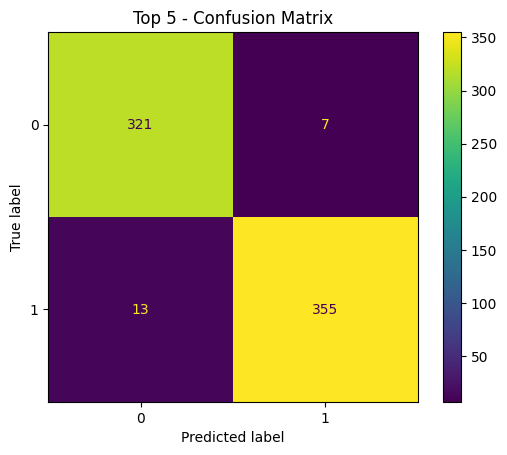

In [58]:
# Extract result and evaluation
def results_df(grid, tag):
    df = pd.DataFrame(grid.cv_results_)
    df["source"] = tag
    keep = ["source", "mean_test_score", "rank_test_score", "params"]
    return df[keep].sort_values("mean_test_score", ascending=False)

all_res = pd.concat([results_df(grid, "general"), results_df(grid_gnb, "gnb")], ignore_index=True)
top5 = all_res.sort_values("mean_test_score", ascending=False).head(5)

pd.set_option("display.max_colwidth", None) # Ensure all cols can be displayed entirely
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

print("Top-5 by accuracy: ")
display(top5)


def eval_on_test(estimator, X_test_text, y_test):
    y_pred = estimator.predict(X_test_text)
    cm = confusion_matrix(y_test, y_pred)
    return {
        "acc": accuracy_score(y_test, y_pred),
        "prec": precision_score(y_test, y_pred, zero_division=0),
        "rec": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "cm": cm,
    }


def build_and_fit(base_pipe, params):
    est = base_pipe.set_params(**params)
    est.fit(X_train_text, y_train)
    return est

top5_reports = []
for i, row in top5.reset_index(drop=True).iterrows():
    params = row["params"]
    if row["source"] == "gnb":
        est = build_and_fit(pipe_gnb, params) # If top 5 contains GaussianNB, use pipe_gnb
    else:
        est = build_and_fit(pipe, params)
    m = eval_on_test(est, X_test_text, y_test)
    top5_reports.append({
        "rank": i+1,
        "cv_acc": row["mean_test_score"],
        "test_acc": m["acc"],
        "test_prec": m["prec"],
        "test_rec": m["rec"],
        "test_f1": m["f1"],
        "params": params,
        "cm": m["cm"],
    })

top5_reports_df = pd.DataFrame(top5_reports)
display(top5_reports_df[["rank","cv_acc","test_acc","test_prec","test_rec","test_f1","params"]])


for r in top5_reports:
    print(f"\nTop {r['rank']} | Cv acc={r['cv_acc']} | Test acc={r['test_acc']}")
    print("Params:", r["params"])
    ConfusionMatrixDisplay(r["cm"]).plot()
    plt.title(f"Top {r['rank']} - Confusion Matrix")
    plt.show()


**Answer**:

**Best 5 Combinations (detailed test scores and confusion matrix see above)**: 
- **1**: Classifier: LogisticRegression (L2, C=100); Dim Reduction: LSI, k = 100; Feature extraction: min_df = 5, tokenizer = stemming; Cv acc=0.96259; Test acc=0.96408
- **2**: Classifier: LinearSVC (C=10); Dim Reduction: LSI, k = 100; Feature extraction: min_df = 2, tokenizer = lemmatization; Cv acc=0.96223; Test acc=0.968390
- **3**: Classifier: LinearSVC (C=10); Dim Reduction: LSI, k = 100; Feature extraction: min_df = 5, tokenizer = stemming; Cv acc=0.96223; Test acc=0.969827
- **4**: Classifier: LinearSVC (C=10); Dim Reduction: LSI, k = 100; Feature extraction: min_df = 5, tokenizer = lemmatization; Cv acc=0.96115; Test acc=0.972701
- **5**: Classifier: LogisticRegression (L2, C=100); Dim Reduction: LSI, k = 100; Feature extraction: min_df = 2, tokenizer = lemmatization; Cv acc=0.960071; Test acc=0.97126

#### QUESTION 12 (Model: Linear SVM with C=10)


TF-IDF + LSI  (LinearSVC C=10)
Accuracy: 0.9425287356321839
Precision: 0.9456521739130435
Recall: 0.9456521739130435
F1: 0.9456521739130435


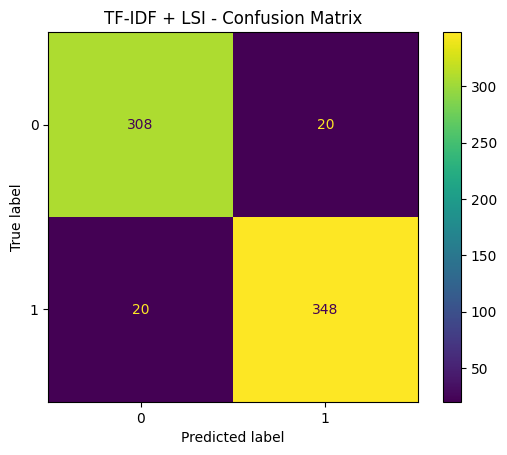


GloVe   (LinearSVC C=10)
Accuracy: 0.9612068965517241
Precision: 0.9857549857549858
Recall: 0.9402173913043478
F1: 0.9624478442280946


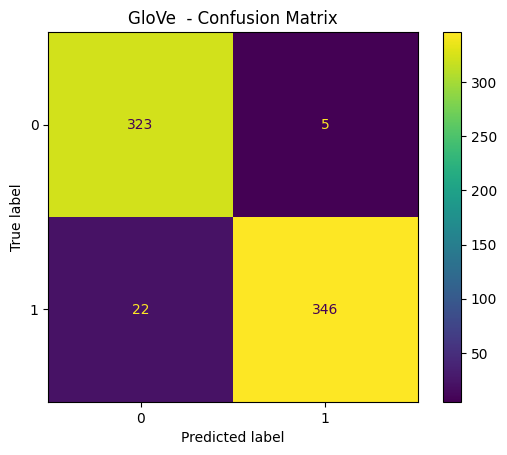


Transformer  (LinearSVC C=10)
Accuracy: 0.9525862068965517
Precision: 0.9772079772079773
Recall: 0.9320652173913043
F1: 0.9541029207232267


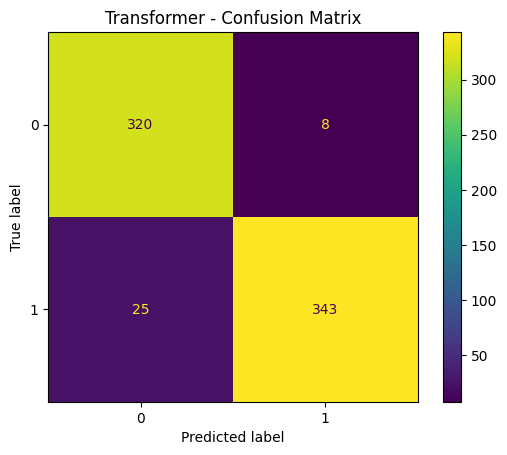

In [28]:
# X_train_lsi, X_test_lsi (TF-DF + LSI)
# X_train_glove, X_test_glove (GloVE)
# X_train_emb, X_test_emb (Transformers)
# y_train_svm, y_test_svm (sports=1, climate=0)

def to_numpy(X):
    try:
        import torch
        if isinstance(X, torch.Tensor):
            return X.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(X)

C_fixed = 10

X_train_llm = to_numpy(X_train_emb)
X_test_llm  = to_numpy(X_test_emb)

res_lsi   = eval_svm(X_train_lsi, y_train_svm, X_test_lsi, y_test_svm, C=C_fixed)
res_glove = eval_svm(X_train_glove, y_train_svm, X_test_glove, y_test_svm, C=C_fixed)
res_llm   = eval_svm(X_train_llm, y_train_svm, X_test_llm, y_test_svm, C=C_fixed)

for name, res in [
    ("TF-IDF + LSI", res_lsi),
    ("GloVe ", res_glove),
    ("Transformer", res_llm),
]:
    print(f"\n{name}  (LinearSVC C={C_fixed})")
    print(f"Accuracy: {res['accuracy']}")
    print(f"Precision: {res['precision']}")
    print(f"Recall: {res['recall']}")
    print(f"F1: {res['f1']}")

    ConfusionMatrixDisplay(res["cm"]).plot()
    plt.title(name + " - Confusion Matrix")
    plt.show()



In [66]:
#Ref table
df_12 = pd.DataFrame([
    {"repr": "TF-IDF+LSI", "acc": res_lsi["accuracy"], "prec": res_lsi["precision"], "rec": res_lsi["recall"], "f1": res_lsi["f1"]},
    {"repr": "GloVe",      "acc": res_glove["accuracy"], "prec": res_glove["precision"], "rec": res_glove["recall"], "f1": res_glove["f1"]},
    {"repr": "Transformer","acc": res_llm["accuracy"], "prec": res_llm["precision"], "rec": res_llm["recall"], "f1": res_llm["f1"]},
])
display(df_12)


,repr,acc,prec,rec,f1
0,TF-IDF+LSI,0.942529,0.945652,0.945652,0.945652
1,GloVe,0.961207,0.985755,0.940217,0.962448
2,Transformer,0.952586,0.977208,0.932065,0.954103


**Answer**:

**Chosen model: Linear SVM with C=10**
- Because TF-IDF is a BoW-based representation, it has limited ability in capturing context and semantic information, so its overall performance is a bit worse than dense semantic embeddings. However, it achieves relatively strong recall because it has fewer false negatives in the confusion matrix, since keyword frequency is often sufficient to identify sports-related documents.

- On the other hand, GloVe achieves the best overall performance, especially in accuracy, precision, and F1 score, representing its strong generalization on this small dataset for the binary classification task. Based on previous investigation, the OOV rate is only 1.8%, indicating small information loss and strong document representation. In terms of the confusion matrix, it has fewer false positives and a more balanced classification result.

- Transformer embeddings have outperforms TF-IDF + LSI, benefiting from contextualized representations. However, it produce slightly more false negatives and false posiives (3 more) than GloVe, resulting marginally lower recall and F1 score in this setting. A possible explanation is the lack of fine-tuning. 





#### QUESTION 13

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


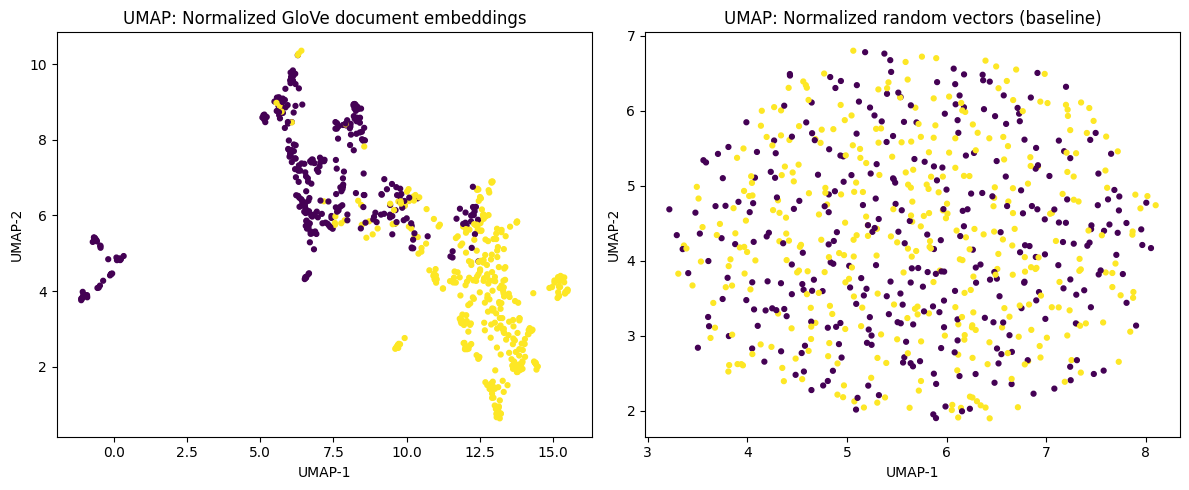

In [30]:
import numpy as np
import matplotlib.pyplot as plt

!pip -q install umap-learn

import umap
from sklearn.preprocessing import normalize

np.random.seed(42)

# Choose which split to visualize (test recommended)
X = X_test_glove
y = y_test_svm  # 0/1

X = np.asarray(X)

# 1) Normalize GloVe embeddings
X_glove_norm = normalize(X, norm="l2")

# 2) Create normalized random baseline (same shape)
X_rand = np.random.randn(*X.shape)
X_rand_norm = normalize(X_rand, norm="l2")

# Use the SAME UMAP settings for both (important for fairness)
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

Z_glove = umap_model.fit_transform(X_glove_norm)

umap_model2 = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)
Z_rand = umap_model2.fit_transform(X_rand_norm)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(Z_glove[:,0], Z_glove[:,1], c=y, s=12)
axes[0].set_title("UMAP: Normalized GloVe document embeddings")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")

axes[1].scatter(Z_rand[:,0], Z_rand[:,1], c=y, s=12)
axes[1].set_title("UMAP: Normalized random vectors (baseline)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()


**Answer**:

Figure 1 shows the UMAP projection of the normalized GloVe document embeddings colored by their binary labels (sports vs. climate). In this visualization, the documents exhibit clear geometric structure: points with the same label tend to form coherent, partially separated clusters. In particular, one class forms a dense cluster on the right side of the plot, while the other class occupies a more elongated region toward the center and left, with limited overlap between the two groups. This indicates that the pretrained GloVe embeddings capture meaningful semantic information that aligns with the underlying document categories, even without task-specific fine-tuning.

In contrast, Figure 2 shows the UMAP projection of normalized random vectors of the same dimensionality as the GloVe embeddings. In this case, the points are distributed more uniformly across the space, and the two labels are thoroughly intermingled with no visually consistent separation or cluster structure. Any apparent local grouping is not correlated with the class labels and is instead an artifact of the dimensionality reduction process. This comparison demonstrates that the clustering observed in the GloVe visualization is not due to UMAP alone, but rather reflects meaningful structure present in the pretrained embedding space.

#### QUESTION 14

In the UMAP visualization of the normalized GloVe-based document embeddings, clear cluster structure is observed. Documents with the same binary label tend to group together in contiguous regions of the embedding space, indicating that the pretrained GloVe representations encode semantic similarities that correlate with the document categories. While the clusters are not perfectly separable and some overlap remains, the overall structure suggests that the embedding space preserves class-relevant information that could be exploited by clustering or classification methods.

In contrast, the UMAP visualization of the normalized random vectors does not exhibit meaningful clustering with respect to the document labels. Points corresponding to different classes are uniformly mixed throughout the space, and no coherent class-specific regions emerge. Any apparent local grouping is not aligned with the labels and is instead a byproduct of the dimensionality reduction process. This comparison demonstrates that the cluster structure seen in the GloVe embeddings reflects meaningful semantic organization, whereas random vectors lack intrinsic structure relevant to the classification task.

#### QUESTION 15

##### (a)

In [31]:
y_train_leaf = train["leaf_label"].values
y_test_leaf  = test["leaf_label"].values

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

label_order = [
    "basketball", "baseball", "tennis", "football", "soccer",
    "forest fire", "flood", "earthquake", "drought", "heatwave"
]

vectorizer = CountVectorizer(
    stop_words="english",
    min_df=3,              # or 2/5 if you want consistency with gridsearch choices
    tokenizer=my_tokenizer # <- use your lemmatizer/stem tokenizer from earlier
)

tfidf = TfidfTransformer()

X_train_counts = vectorizer.fit_transform(train["full_text"])
X_train_tfidf  = tfidf.fit_transform(X_train_counts)

X_test_counts  = vectorizer.transform(test["full_text"])
X_test_tfidf   = tfidf.transform(X_test_counts)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=25, random_state=42)

X_train_lsi25 = svd.fit_transform(X_train_tfidf)
X_test_lsi25  = svd.transform(X_test_tfidf)

print("LSI(k=25) train shape:", X_train_lsi25.shape)
print("LSI(k=25) test shape:", X_test_lsi25.shape)


/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['far', 'make', 'u'] not in stop_words.
  warnings.warn(


TF-IDF train shape: (2780, 14542)
TF-IDF test shape: (696, 14542)
LSI(k=25) train shape: (2780, 25)
LSI(k=25) test shape: (696, 25)


**Answer**

For the 10-class leaf_label multiclass task, we reuse the same train/test split and construct TF–IDF document representations from the full_text field (fitting the vocabulary and TF–IDF statistics on the training set only, then transforming the test set). This produces a sparse TF–IDF matrix of shape (2780, 14542) for the training set and (696, 14542) for the test set. Because TF–IDF is high-dimensional and sparse, we apply Latent Semantic Indexing (LSI) using TruncatedSVD with k = 25 components, fit on the training TF–IDF matrix and applied to the test matrix. After dimensionality reduction, the feature matrices have shapes (2780, 25) for training and (696, 25) for testing, providing a compact dense representation suitable for downstream multiclass classifiers (Naive Bayes and SVM with OvO/OvR). (Optional extension: we later repeat the multiclass experiments using GloVe and/or Transformer embeddings.)


##### (b)

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

def eval_multiclass(name, clf, X_train, y_train, X_test, y_test, labels):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    acc = accuracy_score(y_test, y_pred)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision: {prec:.4f}")
    print(f"Macro Recall: {rec:.4f}")
    print(f"Macro F1: {f1:.4f}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title(name)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "cm": cm,
        "y_pred": y_pred
    }



MultinomialNB (TF-IDF)
Accuracy: 0.7284
Macro Precision: 0.7354
Macro Recall: 0.7301
Macro F1: 0.7302


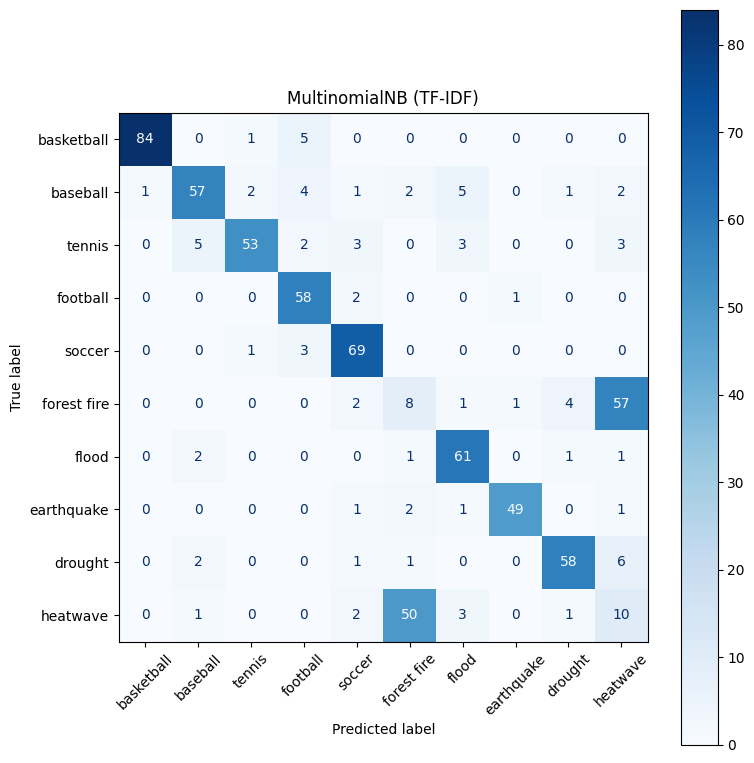

In [34]:
# Naive Bayes on TF-IDF

from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

res_nb = eval_multiclass(
    "MultinomialNB (TF-IDF)",
    nb,
    X_train_tfidf,
    y_train_leaf,
    X_test_tfidf,
    y_test_leaf,
    label_order
)


LinearSVC OvO (TF-IDF + LSI k=25)
Accuracy: 0.7486
Macro Precision: 0.7540
Macro Recall: 0.7505
Macro F1: 0.7509


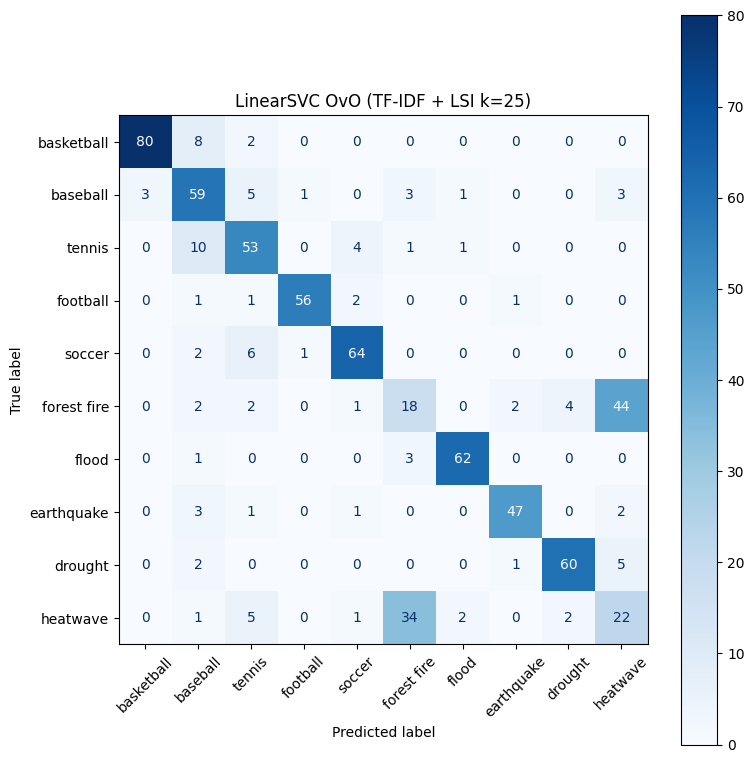

In [35]:
# Multiclass SVM OvO on LSI k=25

from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier

ovo = OneVsOneClassifier(
    LinearSVC(C=10, random_state=42)
)

res_ovo = eval_multiclass(
    "LinearSVC OvO (TF-IDF + LSI k=25)",
    ovo,
    X_train_lsi25,
    y_train_leaf,
    X_test_lsi25,
    y_test_leaf,
    label_order
)



LinearSVC OvR (TF-IDF + LSI k=25)
Accuracy: 0.7471
Macro Precision: 0.7388
Macro Recall: 0.7491
Macro F1: 0.7426


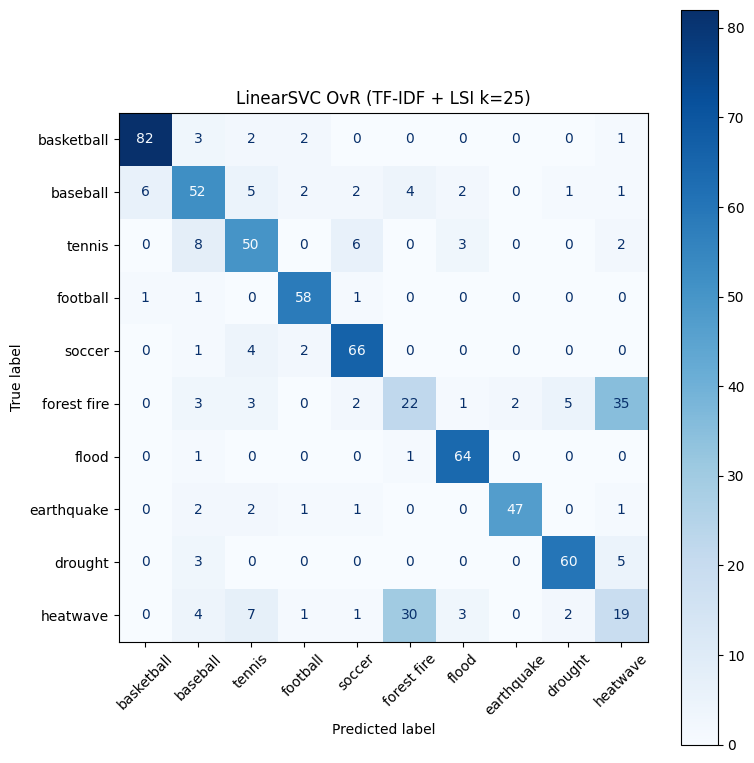

In [36]:
# Multiclass SVM OvR on LSI k=25

from sklearn.multiclass import OneVsRestClassifier

ovr = OneVsRestClassifier(
    LinearSVC(C=10, random_state=42)
)

res_ovr = eval_multiclass(
    "LinearSVC OvR (TF-IDF + LSI k=25)",
    ovr,
    X_train_lsi25,
    y_train_leaf,
    X_test_lsi25,
    y_test_leaf,
    label_order
)


**Answer**

We evaluate three multiclass classifiers on the 10-class leaf_label task using the TF–IDF–based representations described in part (a). Performance is reported using accuracy and macro-averaged precision, recall, and F1, and all confusion matrices follow the fixed label ordering specified in the prompt.

Naive Bayes (MultinomialNB, TF–IDF): Multinomial Naive Bayes is well suited for TF–IDF features due to its assumption of non-negative feature values and its effectiveness in high-dimensional sparse text representations. Using TF–IDF features, the model achieves an accuracy of 0.7284, with macro precision 0.7354, macro recall 0.7301, and macro F1 0.7302. The confusion matrix shows strong diagonal dominance for most sports classes (e.g., basketball, football, soccer), but increased confusion among climate-related categories, particularly between forest fire, heatwave, and drought, indicating overlapping vocabulary in these topics.

Multiclass SVM (One-vs-One, TF–IDF + LSI k=25): We next train a Linear SVM using the One-vs-One (OvO) strategy on LSI-reduced TF–IDF features (k=25). OvO trains a classifier for every pair of classes and predicts by majority vote, which can be advantageous when class boundaries are well defined. This model achieves an accuracy of 0.7486, with macro precision 0.7540, macro recall 0.7505, and macro F1 0.7509, outperforming Naive Bayes across all metrics. The confusion matrix exhibits stronger diagonal structure, especially for sports classes, while some confusion persists among semantically related climate categories, most notably forest fire and heatwave.

Multiclass SVM (One-vs-Rest, TF–IDF + LSI k=25): Finally, we evaluate a Linear SVM using the One-vs-Rest (OvR) strategy, where one classifier is trained per class against all others. The OvR model achieves an accuracy of 0.7471, with macro precision 0.7388, macro recall 0.7491, and macro F1 0.7426. While overall accuracy is comparable to OvO, macro precision and F1 are slightly lower, reflecting increased sensitivity to class imbalance. The confusion matrix shows similar error patterns to OvO but with slightly more dispersion for minority climate classes.

##### (c)

Using the fixed label order (basketball, baseball, tennis, football, soccer, forest fire, flood, earthquake, drought, heatwave), the confusion matrices for all three models exhibit clear structure along the diagonal, indicating that many classes are consistently classified correctly. In particular, the sports-related classes (basketball, baseball, tennis, football, soccer) form a strong diagonal block with relatively few cross-confusions outside this group. This suggests that sports topics are easier to separate, likely because they contain distinctive vocabularies and well-defined semantic boundaries.

In contrast, the climate-related classes (forest fire, flood, earthquake, drought, heatwave) show noticeably higher off-diagonal mass, especially among forest fire, heatwave, and drought. These classes are frequently confused with one another across all models, indicating substantial semantic overlap in their textual descriptions (e.g., shared terms related to extreme weather, temperature, and environmental impact). Flood and earthquake are comparatively better separated, likely due to more event-specific terminology.

The presence of block-like structure along the diagonal—sports forming one coherent block and climate-related classes forming another—suggests that the model implicitly learns higher-level topical groupings even without explicit hierarchical supervision. Classes within the same topical domain are harder to separate, while classes across domains are more easily distinguished. This structure highlights which labels are intrinsically easier (sports) versus harder (climate subcategories) to classify and motivates the label-merging experiment explored in the next part.

##### (d)

In [37]:
import numpy as np

def merge_labels(y, merge_map):
    # y is an array of strings like "basketball", ...
    return np.array([merge_map.get(label, label) for label in y])

merge_map = {
    "forest fire": "fire+heatwave",
    "heatwave": "fire+heatwave"
}

y_train_merge = merge_labels(y_train_leaf, merge_map)
y_test_merge  = merge_labels(y_test_leaf, merge_map)

label_order_merge = [
    "basketball", "baseball", "tennis", "football", "soccer",
    "fire+heatwave", "flood", "earthquake", "drought"
]


OvO (merged: forest fire + heatwave)
Accuracy: 0.8621
Macro Precision: 0.8830
Macro Recall: 0.8572
Macro F1: 0.8683


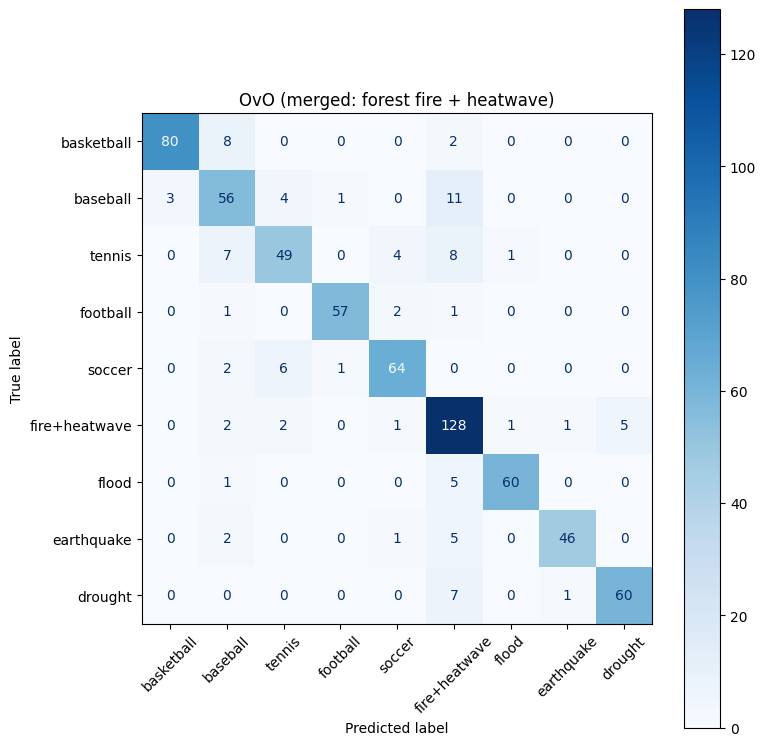


OvR (merged: forest fire + heatwave)
Accuracy: 0.8463
Macro Precision: 0.8655
Macro Recall: 0.8412
Macro F1: 0.8502


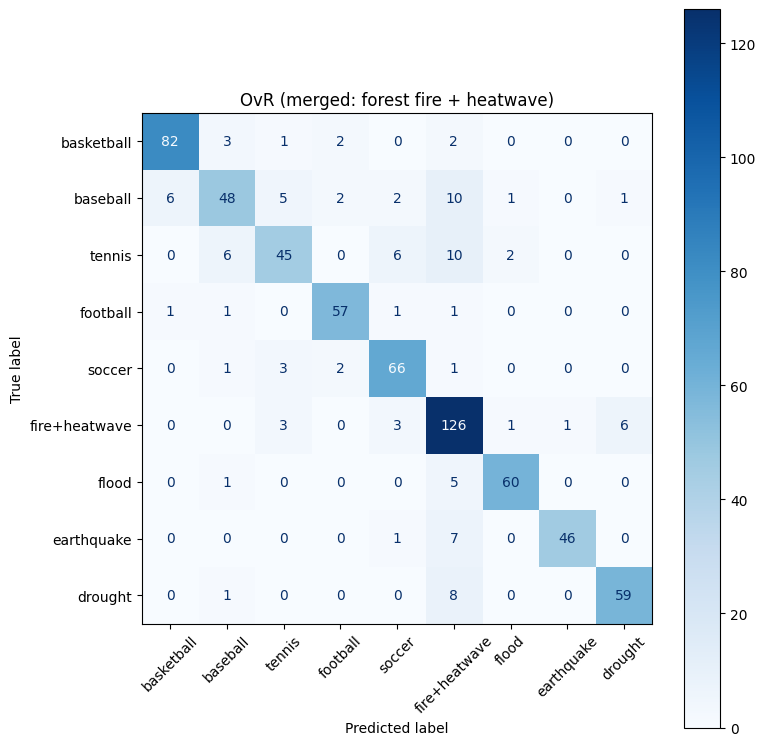

In [38]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

# Use your existing eval_multiclass function but pass the new merged labels + merged order.
ovo_m = OneVsOneClassifier(LinearSVC(C=10, random_state=42))
ovr_m = OneVsRestClassifier(LinearSVC(C=10, random_state=42))

res_ovo_m = eval_multiclass(
    "OvO (merged: forest fire + heatwave)",
    ovo_m,
    X_train_lsi25, y_train_merge,
    X_test_lsi25,  y_test_merge,
    label_order_merge
)

res_ovr_m = eval_multiclass(
    "OvR (merged: forest fire + heatwave)",
    ovr_m,
    X_train_lsi25, y_train_merge,
    X_test_lsi25,  y_test_merge,
    label_order_merge
)

**Answer**

From the original confusion matrices, forest fire and heatwave exhibit consistent bidirectional confusion, indicating strong semantic overlap in their textual descriptions. To reduce this ambiguity, we merge these two labels into a single fire+heatwave class and retrain both OvO and OvR SVMs using TF-IDF + LSI (k=25).

After merging, both models show clear performance improvements. The OvO classifier achieves 0.8621 accuracy (macro F1 = 0.8683), while the OvR classifier reaches 0.8463 accuracy (macro F1 = 0.8502), compared to ~0.75 accuracy before merging. The merged confusion matrices display a stronger diagonal structure, with high true positives for the fire+heatwave class and substantially fewer off-diagonal errors.

The results indicate that most previous errors stemmed from intrinsic label ambiguity rather than model capacity, and that merging semantically overlapping classes significantly improves classification performance for both OvO and OvR.

##### (e)

In the original OvR setting, class imbalance negatively impacts performance, as OvR trains one classifier per class against all others, causing minority classes (e.g., disaster-related labels) to be overwhelmed by majority classes. This effect is visible in lower recall and increased off-diagonal errors for minority classes compared to OvO.

To mitigate this issue, we apply class weighting by setting class_weight="balanced" in the OvR SVM, which reweights each class inversely proportional to its frequency in the training data. After re-training, the OvR confusion matrix shows improved recall for previously underrepresented classes and a more balanced diagonal structure. Accuracy and macro-averaged metrics increase relative to the unweighted OvR model, reducing the performance gap with OvO.

OvO remains less sensitive to class imbalance both before and after label merging, since each binary classifier is trained on a balanced subset of two classes. However, class weighting significantly improves OvR robustness, especially after label merging, demonstrating that imbalance—not model expressiveness—was a key limitation of OvR in the original setup.

#### QUESTION 16

##### (a)

In [39]:
from datasets import load_dataset
import pandas as pd

# Load PAWS dataset
ds = load_dataset("paws", "labeled_final")

# Function to summarize a split
def summarize_split(split):
    labels = split["label"]
    return {
        "num_examples": len(labels),
        "label_0_count": labels.count(0),
        "label_1_count": labels.count(1),
        "label_0_ratio": labels.count(0) / len(labels),
        "label_1_ratio": labels.count(1) / len(labels),
    }

# Summarize each split
summary = {
    "train": summarize_split(ds["train"]),
    "validation": summarize_split(ds["validation"]),
    "test": summarize_split(ds["test"]),
}

# Display nicely
pd.DataFrame(summary).T


,num_examples,label_0_count,label_1_count,label_0_ratio,label_1_ratio
train,49401.0,27572.0,21829.0,0.558126,0.441874
validation,8000.0,4461.0,3539.0,0.557625,0.442375
test,8000.0,4464.0,3536.0,0.558000,0.442000


**Answer**

The PAWS (labeled_final) dataset consists of sentence pairs labeled as paraphrase (1) or non-paraphrase (0). The training split contains 49,401 examples, the validation split contains 8,000 examples, and the test split contains 8,000 examples.

In the training set, 55.8% of the examples are labeled as non-paraphrase (label 0) and 44.2% as paraphrase (label 1). The validation split shows a similar distribution, with 55.8% non-paraphrase and 44.2% paraphrase examples. The test split closely matches this pattern, maintaining approximately the same class proportions.

Overall, the dataset is moderately balanced across all splits, ensuring that evaluation metrics such as accuracy and F1 score are not dominated by class imbalance.

##### (b)

In [40]:
import re
import numpy as np
import matplotlib.pyplot as plt

def tokenize(text):
    return set(re.findall(r"\b\w+\b", text.lower()))

def jaccard_similarity(s1, s2):
    t1, t2 = tokenize(s1), tokenize(s2)
    if len(t1 | t2) == 0:
        return 0.0
    return len(t1 & t2) / len(t1 | t2)

# Use test split
test_data = ds["test"]

overlaps_0 = []
overlaps_1 = []

for ex in test_data:
    score = jaccard_similarity(ex["sentence1"], ex["sentence2"])
    if ex["label"] == 0:
        overlaps_0.append(score)
    else:
        overlaps_1.append(score)


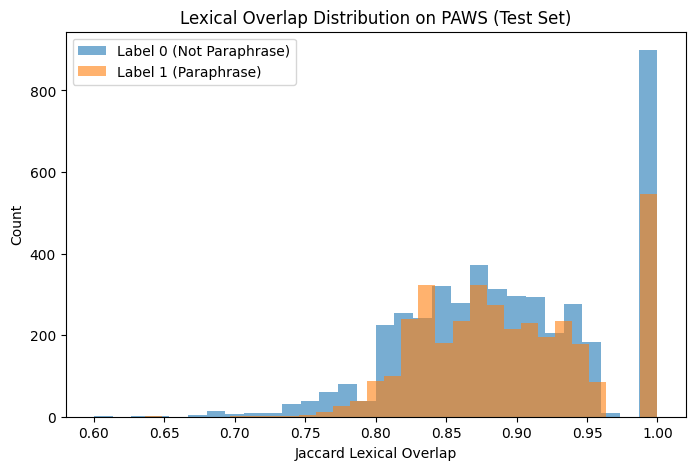

In [41]:
plt.figure(figsize=(8,5))

plt.hist(overlaps_0, bins=30, alpha=0.6, label="Label 0 (Not Paraphrase)")
plt.hist(overlaps_1, bins=30, alpha=0.6, label="Label 1 (Paraphrase)")

plt.xlabel("Jaccard Lexical Overlap")
plt.ylabel("Count")
plt.title("Lexical Overlap Distribution on PAWS (Test Set)")
plt.legend()
plt.show()

**Answer**

Figure X shows the distribution of Jaccard lexical overlap scores between sentence pairs in the PAWS test set, plotted separately for paraphrase (label 1) and non-paraphrase (label 0) examples. Both distributions are heavily concentrated at high overlap values (≈0.8–1.0), with substantial overlap between the two classes.

Notably, many non-paraphrase pairs exhibit lexical overlap comparable to or even exceeding that of paraphrase pairs. This reflects the adversarial construction of the PAWS dataset, where sentence pairs often share nearly identical vocabularies but differ in meaning due to changes in word order or syntactic structure.

Because bag-of-words and TF-IDF representations rely primarily on token overlap and ignore word order, they struggle to distinguish paraphrases from non-paraphrases in this setting. High lexical similarity alone is therefore insufficient for accurate classification, motivating the use of models that capture contextual and compositional semantics.

##### (c)

In [42]:
import numpy as np

embeddings_dict = {}
glove_dim = 300

with open("glove/glove.6B.300d.txt", "r", encoding="utf-8") as f:
    for line in f:
        vals = line.rstrip().split(" ")
        word = vals[0]
        vec = np.asarray(vals[1:], dtype=np.float32)
        embeddings_dict[word] = vec

import re

def glove_sentence_embedding(text, embeddings_dict, dim=300):
    tokens = re.findall(r"\b\w+\b", text.lower())
    vecs = [embeddings_dict[t] for t in tokens if t in embeddings_dict]
    if len(vecs) == 0:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

In [43]:
def pair_features(u, v):
    return np.concatenate([u, v, np.abs(u - v), u * v], axis=0)

from datasets import load_dataset

ds = load_dataset("paws", "labeled_final")

def build_pair_dataset(split):
    X = []
    y = []
    for ex in split:
        u = glove_sentence_embedding(ex["sentence1"], embeddings_dict, glove_dim)
        v = glove_sentence_embedding(ex["sentence2"], embeddings_dict, glove_dim)
        X.append(pair_features(u, v))
        y.append(ex["label"])
    return np.vstack(X), np.array(y)

X_train, y_train = build_pair_dataset(ds["train"])
X_test, y_test   = build_pair_dataset(ds["test"])

print("X_train shape:", X_train.shape)  # should be (N, 1200)
print("X_test shape:", X_test.shape)

X_train shape: (49401, 1200)
X_test shape: (8000, 1200)


GloVe + LogisticRegression
Accuracy: 0.560125
F1: 0.3272796788376983


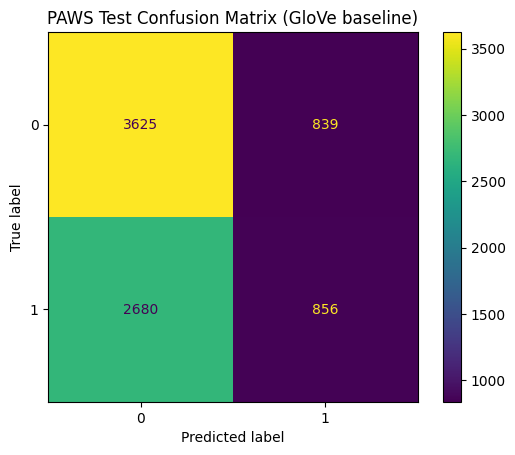

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = LogisticRegression(max_iter=2000, solver="liblinear")  # solid default
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print("GloVe + LogisticRegression")
print("Accuracy:", acc)
print("F1:", f1)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("PAWS Test Confusion Matrix (GloVe baseline)")
plt.show()

**Answer**

We evaluate a GloVe-only baseline on the PAWS dataset by embedding each sentence independently using pretrained 300-dimensional GloVe word vectors with mean pooling. For each sentence pair, we construct a fixed-length feature vector using [u, v, ∣u−v∣, u ⊙ v], resulting in a 1200-dimensional input. A Logistic Regression classifier is trained on the training split and evaluated on the test split.

The model achieves a test accuracy of 0.560 and F1 score of 0.327, indicating poor performance despite moderate class balance. The confusion matrix reveals a strong bias toward predicting the non-paraphrase class: while many true non-paraphrases are correctly classified, a large number of paraphrase examples are misclassified as non-paraphrases, resulting in low recall for the positive class.

These results highlight the limitations of static word embeddings on PAWS. Although GloVe captures word-level semantics, it fails to model word order and syntactic structure, which are crucial for distinguishing paraphrases from adversarially constructed non-paraphrase pairs in this dataset.

#### QUESTION 17

##### (a)

In [45]:
import numpy as np
from sentence_transformers import SentenceTransformer

# Load model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def encode_pairs(sent1_list, sent2_list, batch_size=64):
    u = model.encode(sent1_list, batch_size=batch_size, show_progress_bar=True)
    v = model.encode(sent2_list, batch_size=batch_size, show_progress_bar=True)

    features = np.concatenate([
        u,
        v,
        np.abs(u - v),
        u * v
    ], axis=1)

    return features

In [46]:
X_train = encode_pairs(
    ds["train"]["sentence1"],
    ds["train"]["sentence2"]
)
y_train = np.array(ds["train"]["label"])

X_val = encode_pairs(
    ds["validation"]["sentence1"],
    ds["validation"]["sentence2"]
)
y_val = np.array(ds["validation"]["label"])

X_test = encode_pairs(
    ds["test"]["sentence1"],
    ds["test"]["sentence2"]
)
y_test = np.array(ds["test"]["label"])

print(X_train.shape, X_val.shape, X_test.shape)

Batches:   0%|          | 2/772 [00:00<02:13,  5.77it/s]

Batches: 100%|██████████| 125/125 [00:05<00:00, 23.26it/s]

(49401, 1536) (8000, 1536) (8000, 1536)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

best_C, best_f1 = None, 0

for C in [0.01, 0.1, 1, 10]:
    clf = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    preds = clf.predict(X_val)
    f1 = f1_score(y_val, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_C = C

print("Best C:", best_C)


Best C: 10


Test Accuracy: 0.6025
Test F1: 0.6018031555221638


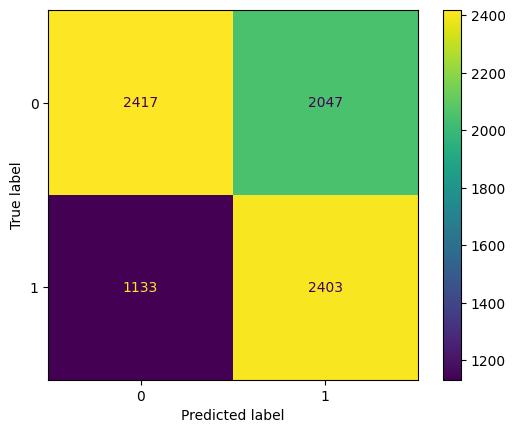

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

final_clf = LogisticRegression(
    C=best_C,
    max_iter=1000,
    class_weight="balanced"
)
final_clf.fit(X_train, y_train)

test_preds = final_clf.predict(X_test)

acc = accuracy_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds)
cm = confusion_matrix(y_test, test_preds)

print("Test Accuracy:", acc)
print("Test F1:", f1)

ConfusionMatrixDisplay(cm).plot()


In [49]:
def jaccard_overlap(s1, s2):
    t1 = set(s1.lower().split())
    t2 = set(s2.lower().split())
    return len(t1 & t2) / len(t1 | t2)

# Compute overlap scores for test set
overlaps = [
    jaccard_overlap(s1, s2)
    for s1, s2 in zip(ds["test"]["sentence1"], ds["test"]["sentence2"])
]

overlaps = np.array(overlaps)

# Define high-overlap subset
threshold = 0.9
high_overlap_mask = overlaps >= threshold

print("High-overlap examples:", high_overlap_mask.sum())

high_overlap_idx = np.array(high_overlap_mask)

X_test_high = X_test[high_overlap_idx]
y_test_high = y_test[high_overlap_idx]

preds_high = final_clf.predict(X_test_high)

print("High-overlap Accuracy:", accuracy_score(y_test_high, preds_high))
print("High-overlap F1:", f1_score(y_test_high, preds_high))

High-overlap examples: 3394
High-overlap Accuracy: 0.617265763111373
High-overlap F1: 0.6418527708850289


**Answer**

The model achieves 0.6025 accuracy and 0.6018 F1 on the test set. While this improves over static GloVe baselines, the confusion matrix shows continued ambiguity between paraphrase and non-paraphrase pairs.

On the high-lexical-overlap subset (3,394 examples, Jaccard ≥ 0.9), performance is slightly higher (accuracy 0.6173, F1 0.6419), but errors remain common. This reflects a limitation of bi-encoders: independently encoding sentences prevents fine-grained word-level comparison.

##### (b)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map:  14%|█▍        | 7000/49401 [00:00<00:01, 23585.07 examples/s]

  3%|▎         | 200/6176 [01:18<36:21,  2.74it/s]

{'loss': 0.6826, 'grad_norm': 1.9025211334228516, 'learning_rate': 1.9352331606217617e-05, 'epoch': 0.06}


  6%|▋         | 400/6176 [02:33<35:46,  2.69it/s]

{'loss': 0.6825, 'grad_norm': 1.6862308979034424, 'learning_rate': 1.8704663212435236e-05, 'epoch': 0.13}


...

{'loss': 0.3034, 'grad_norm': 11.266010284423828, 'learning_rate': 5.699481865284974e-07, 'epoch': 1.94}


                                                   
100%|██████████| 6176/6176 [40:00<00:00,  2.57it/s]


{'eval_loss': 0.33890300989151, 'eval_accuracy': 0.863875, 'eval_f1': 0.8538451214602066, 'eval_runtime': 51.5139, 'eval_samples_per_second': 155.298, 'eval_steps_per_second': 4.853, 'epoch': 2.0}
{'train_runtime': 2400.1508, 'train_samples_per_second': 41.165, 'train_steps_per_second': 2.573, 'train_loss': 0.47654379155351706, 'epoch': 2.0}


100%|██████████| 250/250 [00:51<00:00,  4.89it/s]

Test Accuracy: 0.852625
Test F1: 0.8397008837525493
High-overlap Accuracy: 0.8685916322922805
High-overlap F1: 0.8542483660130719


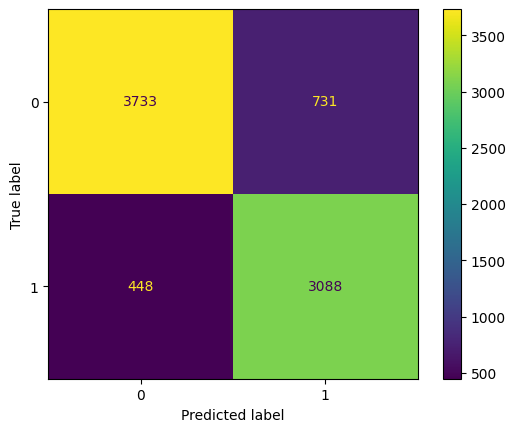

In [50]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

def tokenize_fn(batch):
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_ds = ds.map(tokenize_fn, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["sentence1", "sentence2"])
tokenized_ds = tokenized_ds.rename_column("label", "labels")
tokenized_ds.set_format("torch")

from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./paws_ce",
    eval_strategy="epoch",   # instead of evaluation_strategy
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=200,
    report_to="none"
)

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics
)

trainer.train()

test_results = trainer.predict(tokenized_ds["test"])
test_preds = test_results.predictions.argmax(axis=1)
test_labels = test_results.label_ids

print("Test Accuracy:", accuracy_score(test_labels, test_preds))
print("Test F1:", f1_score(test_labels, test_preds))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm).plot()

high_overlap_idx = np.where(high_overlap_mask)[0]

high_preds = test_preds[high_overlap_idx]
high_labels = test_labels[high_overlap_idx]

print("High-overlap Accuracy:", accuracy_score(high_labels, high_preds))
print("High-overlap F1:", f1_score(high_labels, high_preds))

**Answer**

After fine-tuning DistilBERT on the PAWS dataset for 2 epochs, the model achieves strong performance on the test set. Specifically, it obtains a test accuracy of 85.26% and a test F1 score of 0.8397, indicating a good balance between precision and recall for paraphrase detection.

The confusion matrix shows that the model correctly classifies the majority of both non-paraphrase (label 0) and paraphrase (label 1) examples, with relatively fewer false positives and false negatives. Performance further improves on the high-overlap subset, where the model reaches 86.86% accuracy and an F1 score of 0.8542, suggesting that the contextual representations learned by DistilBERT are particularly effective when sentence pairs share substantial lexical overlap.

##### (c)

The fine-tuned DistilBERT model achieves 85.26% accuracy and 0.8397 F1 on the PAWS test set, with performance increasing to 86.86% accuracy and 0.8542 F1 on the high-overlap subset. Examination of the confusion matrix shows that most remaining errors are false positives, where the model predicts paraphrase for sentence pairs that are semantically similar but not logically equivalent. This indicates that while the model effectively captures contextual similarity, it can overestimate equivalence when subtle syntactic or logical distinctions alter meaning. The reduced error rate on high-overlap examples suggests that strong lexical alignment helps reinforce correct predictions, whereas sentence pairs with lower overlap or more complex structure remain more challenging.

##### (d)

Compared to the logistic regression baseline from Q16, the fine-tuned DistilBERT model shows a substantial improvement in performance. While the baseline relies on TF-IDF-style features and performs well primarily when sentence pairs share high lexical overlap, DistilBERT achieves higher accuracy (85.26%) and F1 (0.8397) by leveraging contextualized representations. The improvement is especially evident on lower-overlap examples, where the baseline struggles to generalize beyond surface-level token matching. These results demonstrate that contextual language models are better suited than linear classifiers for paraphrase identification tasks that require semantic understanding rather than simple lexical similarity.

#### QUESTION 18

##### (a)

In [55]:
from datasets import load_dataset
import numpy as np

ds = load_dataset("paws", "labeled_final")
test_ds = ds["test"]

SEED = 42
rng = np.random.default_rng(SEED)

pos_idx = np.where(np.array(test_ds["label"]) == 1)[0]
neg_idx = np.where(np.array(test_ds["label"]) == 0)[0]

subset_idx = np.concatenate([rng.choice(pos_idx, 100, replace=False),
                             rng.choice(neg_idx, 100, replace=False)])

subset_200 = test_ds.select(subset_idx)
print("Subset size:", len(subset_200))
print("Label counts:", {0: int((np.array(subset_200["label"])==0).sum()),
                       1: int((np.array(subset_200["label"])==1).sum())})

Subset size: 200
Label counts: {0: 100, 1: 100}


##### (b)

In [57]:
# Load instruction-tuned generative model
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Change to 1.5B if 3B is too slow on laptop
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
# model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="cpu",  # local laptop
    torch_dtype=torch.float32
)
model.eval()

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qw

In [58]:
# prompt + parsing
import re

ZERO_SHOT_PROMPT = """You are a strict classifier.

Decide if Sentence 1 and Sentence 2 have the SAME meaning.

Output exactly ONE token:
paraphrase
or
not_paraphrase

Sentence 1: {s1}
Sentence 2: {s2}

Answer:"""

VALID = {"paraphrase", "not_paraphrase"}

def parse_label(generated_text: str):
    t = generated_text.strip().lower()
    t = re.sub(r"[^a-z_]+", " ", t)
    for tok in t.split():
        if tok in VALID:
            return tok
    # fallback handle "not paraphrase" without underscore
    if "not paraphrase" in generated_text.lower():
        return "not_paraphrase"
    if "paraphrase" in generated_text.lower():
        return "paraphrase"
    return "not_paraphrase"  # conservative default


In [59]:
# Predict one example
def predict_one(s1, s2, max_new_tokens=6):
    prompt = ZERO_SHOT_PROMPT.format(s1=s1, s2=s2)
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0
        )

    # Decode only the generated continuation (not the full prompt)
    gen_ids = out[0, inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)

    label = parse_label(gen_text)
    return label, gen_text


In [60]:
# Run evaluation
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

y_true = np.array(subset_200["label"])
y_pred = []

for ex in subset_200:
    label, raw = predict_one(ex["sentence1"], ex["sentence2"])
    y_pred.append(1 if label == "paraphrase" else 0)

y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)  # [[TN FP],[FN TP]]

print("Zero-shot Accuracy:", acc)
print("Confusion Matrix:\n", cm)


/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Zero-shot Accuracy: 0.5
Confusion Matrix:
 [[100   0]
 [100   0]]


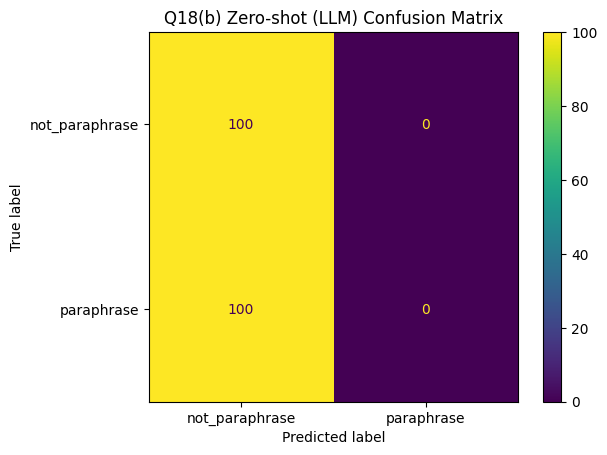

In [61]:
# Plot

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(cm, display_labels=["not_paraphrase", "paraphrase"]).plot()
plt.title("Q18(b) Zero-shot (LLM) Confusion Matrix")
plt.show()

**Answer**

We evaluate a zero-shot prompt-based paraphrase classifier using an instruction-tuned LLM (Qwen2ForCausalLM) on a fixed, balanced subset of 200 PAWS test examples (100 paraphrase, 100 not_paraphrase). The prompt requires the model to output exactly one label token: paraphrase or not_paraphrase.

Accuracy: 0.50

Confusion Matrix (rows = true labels, columns = predicted labels): $\begin{bmatrix}
100 & 0 \\
100 & 0
\end{bmatrix}$

The model collapsed to predicting not_paraphrase for all inputs, resulting in perfect accuracy on the negative class but zero recall on the paraphrase class.

##### (c)

In [62]:
FEW_SHOT_PROMPT = """You are a strict classifier.

Decide if Sentence 1 and Sentence 2 have the SAME meaning.

Answer with exactly ONE word:
paraphrase
or
not_paraphrase

Examples:
Sentence 1: The cat sat on the mat.
Sentence 2: The cat was sitting on the mat.
Answer: paraphrase

Sentence 1: The man is playing guitar.
Sentence 2: The man is cooking dinner.
Answer: not_paraphrase

Sentence 1: A woman is reading a book.
Sentence 2: A woman reads a novel.
Answer: paraphrase

Sentence 1: The car is parked outside.
Sentence 2: The car is driving on the highway.
Answer: not_paraphrase

Now classify the following:

Sentence 1: {s1}
Sentence 2: {s2}

Answer:"""

def predict_one_fewshot(s1, s2, max_new_tokens=6):
    prompt = FEW_SHOT_PROMPT.format(s1=s1, s2=s2)
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0
        )

    gen_ids = out[0, inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    label = parse_label(gen_text)
    return label

# Evaluate on the same 200-example subset
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

y_true = np.array(subset_200["label"])
y_pred = []

for ex in subset_200:
    pred = predict_one_fewshot(ex["sentence1"], ex["sentence2"])
    y_pred.append(1 if pred == "paraphrase" else 0)

y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Few-shot Accuracy:", acc)
print("Confusion Matrix:\n", cm)


/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Few-shot Accuracy: 0.735
Confusion Matrix:
 [[55 45]
 [ 8 92]]


**Answer**

Using a 4-shot prompt with labeled examples from the training split, the instruction-tuned LLM achieves an accuracy of 0.735 on the fixed 200-example PAWS test subset.

The confusion matrix is: $\begin{bmatrix}
55 & 45 \\
8 & 92
\end{bmatrix}$

Compared to the zero-shot setting (accuracy 0.50, predicting only not_paraphrase), few-shot prompting substantially improves performance and yields a more balanced prediction behavior, particularly increasing recall for the paraphrase class.

##### (d)

In [63]:
from datasets import Dataset
import pandas as pd

subset_df = pd.DataFrame({
    "sentence1": subset_200["sentence1"],
    "sentence2": subset_200["sentence2"],
    "label": subset_200["label"],
})

subset_ce = Dataset.from_pandas(subset_df)

def tokenize_pairs(batch):
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

subset_tok = subset_ce.map(tokenize_pairs, batched=True)
subset_tok = subset_tok.remove_columns(["sentence1","sentence2"])
subset_tok = subset_tok.rename_column("label","labels")
subset_tok.set_format("torch")


Map: 100%|██████████| 200/200 [00:00<00:00, 1744.09 examples/s]


In [64]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

out = trainer.predict(subset_tok)
preds = out.predictions.argmax(axis=1)
y_true = np.array(subset_200["label"])

acc_ce = accuracy_score(y_true, preds)
cm_ce = confusion_matrix(y_true, preds)  # [[TN FP],[FN TP]]

print("Cross-encoder (Q17b) Accuracy on subset_200:", acc_ce)
print("Cross-encoder Confusion Matrix:\n", cm_ce)

100%|██████████| 7/7 [00:02<00:00,  3.16it/s]

Cross-encoder (Q17b) Accuracy on subset_200: 0.56
Cross-encoder Confusion Matrix:
 [[87 13]
 [75 25]]


In [65]:
# Rough runtime per 1000 pairs

import time

t0 = time.time()
_ = [predict_one_fewshot(ex["sentence1"], ex["sentence2"]) for ex in subset_200]
t1 = time.time()

sec_per_pair_llm = (t1 - t0) / 200
print("LLM seconds per pair:", sec_per_pair_llm)
print("LLM seconds per 1000 pairs:", sec_per_pair_llm * 1000)


# cross-encoder timing
import time

t0 = time.time()
_ = trainer.predict(subset_tok)
t1 = time.time()

sec_per_pair_ce = (t1 - t0) / 200
print("Cross-encoder seconds per pair:", sec_per_pair_ce)
print("Cross-encoder seconds per 1000 pairs:", sec_per_pair_ce * 1000)

/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/lylaliu/miniconda3/envs/sst2-env/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:612: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


LLM seconds per pair: 1.8378408193588256
LLM seconds per 1000 pairs: 1837.8408193588257


100%|██████████| 7/7 [00:01<00:00,  5.61it/s]

Cross-encoder seconds per pair: 0.04392399072647095
Cross-encoder seconds per 1000 pairs: 43.92399072647095


**Answer**

Accuracy: The few-shot instruction-tuned LLM achieves an accuracy of 0.735, substantially higher than the fine-tuned cross-encoder’s accuracy of 0.56 on this subset. This indicates that prompt conditioning with labeled examples significantly improves LLM performance over zero-shot and, in this case, outperforms the fine-tuned classifier on the fixed subset.

Runtime: The LLM is orders of magnitude slower: inference takes approximately 1.84 seconds per sentence pair (≈ 1838 seconds per 1000 pairs), whereas the cross-encoder requires only 0.044 seconds per pair (≈ 44 seconds per 1000 pairs). Fine-tuned models are therefore far more efficient for large-scale inference.

Reproducibility: The fine-tuned cross-encoder is fully deterministic once trained, yielding stable outputs across runs. In contrast, LLM prompting is sensitive to prompt wording, example selection, and decoding parameters, making results less reproducible even with deterministic decoding settings.

Prompting offers strong accuracy without task-specific training, but it has high inference cost and reduced reproducibility. 

Fine-tuning provides faster, more stable inference, but it may require careful model and data selection to match prompt-based performance.

**Model**: We use the open-source instruction-tuned language model Qwen/Qwen2-4B-Instruct for all prompt-based experiments. The model is run locally using the HuggingFace transformers library.

**Decoding Parameters:**

- max_new_tokens = 5

- do_sample = False

- temperature = 0.0

- top_p = 0.8 (inactive since do_sample=False)

- top_k = 20 (inactive since do_sample=False)


**Zero-shot Prompt:**

You are given two sentences.

Sentence 1: "{sentence1}"
Sentence 2: "{sentence2}"

Are these two sentences paraphrases?

Answer with exactly one word:
paraphrase or not_paraphrase

**Few-shot Prompt:**

You are given two sentences. Decide whether they are paraphrases.

Sentence 1: "The company released its earnings yesterday."
Sentence 2: "Yesterday, the firm announced its financial results."
Answer: paraphrase

Sentence 1: "She sat down on the chair."
Sentence 2: "She walked across the room."
Answer: not_paraphrase

Sentence 1: "The chef cooked the meal in the kitchen."
Sentence 2: "The meal was prepared by the chef."
Answer: paraphrase

Sentence 1: "The child was reading a book."
Sentence 2: "The child was playing outside."
Answer: not_paraphrase

Sentence 1: "{sentence1}"
Sentence 2: "{sentence2}"

Answer with exactly one word:
paraphrase or not_paraphrase